# DORAnet → enzyme hypotheses → DNA design

This notebook converts DORAnet-generated reaction networks into concise downstream design tables: parsed reactions, enzyme hypotheses, enzyme-candidate templates, and non-operational DNA design plans for expert review.

In [1]:
from pathlib import Path
import glob
import json
import os
import re
import textwrap
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from rdkit import Chem, rdBase
from rdkit.Chem import rdmolfiles, Draw
from IPython.display import display
import time
import requests
from io import StringIO
import ast
import sys
from tqdm.auto import tqdm
tqdm.pandas()

from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

from Bio.Data import CodonTable

from dnachisel import (
    DnaOptimizationProblem,
    EnforceTranslation,
    EnforceGCContent,
    AvoidPattern,
    MaximizeCAI,
)

import hashlib

/users/sghosh6/.conda/envs/doranet_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/users/sghosh6/.conda/envs/doranet_env/lib/python3.10/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
resultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW_allDB_generative/')
DORANETmoleculesDataDir = os.path.join(resultsDir, 'DORAnet/InoAdeGuoXan/PATHWAY_reconstruction/')
#DORANETmoleculesDataDir = os.path.join(resultsDir, 'DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run2/')
DNADesignResultsDir = os.path.join(resultsDir, 'DNA_design/')
os.makedirs(DNADesignResultsDir, exist_ok=True)

print("Reading DORAnet results from:", DORANETmoleculesDataDir)
print("DNA design results will be saved at:", DNADesignResultsDir)

Reading DORAnet results from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction/
DNA design results will be saved at: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/


## 0. Read list of target DORAnet compounds

In [3]:
targetCompound_DF = pd.read_csv(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv")
targetCompound_DF

,Rank,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
0,1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,6.156,0.476241,0.697981
1,2,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,5.989,0.473052,1.025573
2,3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.907,0.473610,1.238912
3,4,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.825,0.472941,1.495337
4,5,CC(=O)OP(=O)(O)OC(C)=O,5.758,0.479591,1.747229
5,6,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.729,0.473567,1.865382
6,7,CC(=O)OP(=O)(O)OP(=O)(O)O,5.693,0.478908,2.026785
7,8,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.692,0.473252,2.030622
8,9,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.683,0.471067,2.074770
9,10,O=C(O)CC(=O)OP(=O)(O)O,5.679,0.476017,2.094051


In [4]:
DORANETmoleculesDataDir = Path(DORANETmoleculesDataDir)

def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

def canonicalizeSmilesCollection(x):
    if not isinstance(x, (set, list, tuple)):
        return []
    out = []
    for s in x:
        c = canonicalizeSmiles(s)
        if c is not None:
            out.append(c)
    return sorted(set(out))

def parseLiteralFromScript(text, varName):
    # captures lines like: varName = {...} or varName = 3
    m = re.search(rf"^\s*{re.escape(varName)}\s*=\s*(.+)\s*$", text, flags=re.MULTILINE)
    if not m:
        return None
    raw = m.group(1).strip()
    try:
        return ast.literal_eval(raw)
    except Exception:
        return None

allReproFiles = sorted(
    DORANETmoleculesDataDir.rglob("reproDoranetJob.py"),
    key=lambda p: str(p).lower()
)

records = []
for reproPath in allReproFiles:
    txt = reproPath.read_text(encoding="utf-8", errors="ignore")

    startersRaw = parseLiteralFromScript(txt, "starters")
    targetRaw = parseLiteralFromScript(txt, "target")
    maxAtomsRaw = parseLiteralFromScript(txt, "maxAtoms")
    generationsRaw = parseLiteralFromScript(txt, "generations")

    records.append({
        "dirName": reproPath.parent.name,
        "starters": canonicalizeSmilesCollection(startersRaw),
        "target": canonicalizeSmilesCollection(targetRaw),
        "maxAtoms": maxAtomsRaw if isinstance(maxAtomsRaw, dict) else None,
        "generations": int(generationsRaw) if generationsRaw is not None else None,
    })

targetCompoundDir_DF = pd.DataFrame(records, columns=["dirName", "starters", "target", "maxAtoms", "generations"])

print(f"Total DORAnet configuration files: {len(targetCompoundDir_DF)}")

# targetCompoundDir_DF["target"] is a list (usually one SMILES). Create join key from first target SMILES.
targetCompoundDir_DF = targetCompoundDir_DF.copy()
targetCompoundDir_DF["targetSmiles"] = targetCompoundDir_DF["target"].apply(
    lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) > 0 else None
)

# Add columns from targetCompound_DF by matching Canonical_SMILES == targetSmiles
colsToAdd = ["Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
targetCompoundDir_DF = targetCompoundDir_DF.merge(
    targetCompound_DF[colsToAdd].drop_duplicates(subset=["Canonical_SMILES"]),
    left_on="targetSmiles",
    right_on="Canonical_SMILES",
    how="left"
).drop(columns=["Canonical_SMILES"])


targetCompoundDir_DF = targetCompoundDir_DF.drop(columns=["targetSmiles"])
targetCompoundDir_DF = targetCompoundDir_DF.rename(columns={'starters':'starters_Canonical_SMILES', 'target':'target_Canonical_SMILES'})
targetCompoundDir_DF["starters_Canonical_SMILES"] = targetCompoundDir_DF["starters_Canonical_SMILES"].apply(
    lambda x: ".".join(x) if isinstance(x, (list, tuple)) else ("" if pd.isna(x) else str(x))
)

targetCompoundDir_DF["target_Canonical_SMILES"] = targetCompoundDir_DF["target_Canonical_SMILES"].apply(
    lambda x: ".".join(x) if isinstance(x, (list, tuple)) else ("" if pd.isna(x) else str(x))
)
targetCompoundDir_DF = targetCompoundDir_DF.sort_values(
    by="pPotency_prediction",
    ascending=False
).reset_index(drop=True)
targetCompoundDir_DF 

Total DORAnet configuration files: 20


,dirName,starters_Canonical_SMILES,target_Canonical_SMILES,maxAtoms,generations,pPotency_prediction,pPotency_std,IC50 (µM)
0,high_pPotency_molecule_pathway1,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,6.156,0.476241,0.697981
1,high_pPotency_molecule_pathway2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.989,0.473052,1.025573
2,high_pPotency_molecule_pathway3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.907,0.473610,1.238912
3,high_pPotency_molecule_pathway4,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.825,0.472941,1.495337
4,high_pPotency_molecule_pathway5,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)OP(=O)(O)OC(C)=O,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.758,0.479591,1.747229
5,high_pPotency_molecule_pathway6,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.729,0.473567,1.865382
6,high_pPotency_molecule_pathway7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(=O)OP(=O)(O)OP(=O)(O)O,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.693,0.478908,2.026785
7,high_pPotency_molecule_pathway8,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.692,0.473252,2.030622
8,high_pPotency_molecule_pathway9,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.683,0.471067,2.074770
9,high_pPotency_molecule_pathway10,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C(O)CC(=O)OP(=O)(O)O,"{'C': 15, 'N': 6, 'O': 8, 'S': 3}",3,5.679,0.476017,2.094051


## 1. Read DORAnet reaction network files

In [5]:
DORANETmoleculesDataDir = Path(DORANETmoleculesDataDir)  

def extractFirstInt(text):
    match = re.search(r"\d+", text)
    return int(match.group(0)) if match else -1

# Find all JSON files anywhere under root
allJsonPaths = sorted(DORANETmoleculesDataDir.rglob("*.json"), key=lambda p: str(p).lower())

fileInfoList = []
for jsonPath in allJsonPaths:
    parentDir = jsonPath.parent
    fileInfoList.append({
        "dirName": parentDir.name,
        "dirPath": str(parentDir),
        "jsonName": jsonPath.name,
        "jsonPath": str(jsonPath),
        "folderNum": extractFirstInt(parentDir.name),  # optional helper field
    })

print(f"Root directory        : {DORANETmoleculesDataDir}")
print(f"JSON files found      : {len(fileInfoList)}")
print(f"Unique folders w/JSON : {len({x['dirPath'] for x in fileInfoList})}")

Root directory        : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction
JSON files found      : 20
Unique folders w/JSON : 20


## 2. Parse DORAnet reaction strings

In [6]:
def splitMoleculeString(moleculeString):
    return [mol for mol in str(moleculeString).split(".") if mol]

def parseDoranetReaction(rxnString, fileInfo):
    parts = str(rxnString).split(">")
    if len(parts) != 4:
        raise ValueError(f"Expected 4 fields separated by '>'; found {len(parts)}")

    reactants, ruleName, metaBlock, products = parts
    metaParts = (metaBlock.split("$") + [None, None, None, None])[:4]
    thermo, reactantStoich, productStoich, reactionType = metaParts

    return {
        "reactants": reactants,
        "products": products,
        "reactionString": f"{reactants} >> {products}",
        "ruleName": ruleName,
        "thermo": thermo,
        "reactantStoich": reactantStoich,
        "productStoich": productStoich,
        "reactionType": reactionType,
        "numReactantMolecules": len(splitMoleculeString(reactants)),
        "numProductMolecules": len(splitMoleculeString(products)),
        "sourceFolderNum": fileInfo.get("folderNum", -1),
        "sourceDirectory": fileInfo.get("dirName", ""),
        "sourceDirectoryPath": fileInfo.get("dirPath", ""),
        "sourceJsonName": fileInfo.get("jsonName", ""),
        "sourceJsonPath": fileInfo.get("jsonPath", ""),
    }

reactionRecords = []
jsonReadErrors = []
uniqueReactantMolecules = set()
uniqueProductMolecules = set()

for fileInfo in tqdm(fileInfoList, desc="Reading DORAnet JSON"):
    try:
        with open(fileInfo["jsonPath"], "r", encoding="utf-8") as f:
            reactionList = json.load(f)

        # handle both list and dict payloads
        if isinstance(reactionList, dict):
            # try common key names; otherwise fail clearly
            for k in ["reactions", "reactionList", "data"]:
                if k in reactionList and isinstance(reactionList[k], list):
                    reactionList = reactionList[k]
                    break
            else:
                raise ValueError("JSON is dict but no reaction list key found")

        if not isinstance(reactionList, list):
            raise ValueError(f"Expected list of reaction strings, got {type(reactionList)}")

        for rxnString in reactionList:
            record = parseDoranetReaction(rxnString, fileInfo)
            reactionRecords.append(record)
            uniqueReactantMolecules.update(splitMoleculeString(record["reactants"]))
            uniqueProductMolecules.update(splitMoleculeString(record["products"]))

    except Exception as exc:
        jsonReadErrors.append({**fileInfo, "error": str(exc)})

if not reactionRecords:
    raise RuntimeError("No reactions loaded. Check JSON discovery and reaction format.")

reactionDF = pd.DataFrame(reactionRecords).reset_index(drop=True)

# safer path handling
outputPath = Path(DNADesignResultsDir) / "reactionDF.csv"
reactionDF.to_csv(outputPath, index=False)

print(f"Reactions loaded     : {len(reactionDF):,}")
print(f"Failed JSON files    : {len(jsonReadErrors):,}")
print(f"Unique reactant mols : {len(uniqueReactantMolecules):,}")
print(f"Unique product mols  : {len(uniqueProductMolecules):,}")
print(f"Saved: {outputPath}")

reactionDF.head()

Reading DORAnet JSON: 100%|████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 20.76it/s]


Reactions loaded     : 176,400
Failed JSON files    : 0
Unique reactant mols : 283
Unique product mols  : 4,730
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/reactionDF.csv


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath
0,CO[C@@H]1[C@H](OC(C)=O)[C@@H](CO)O[C@H]1n1cnc2...,CO[C@@H]1[C@H](OC(C)=O)[C@@H](C=O)O[C@H]1n1cnc...,CO[C@@H]1[C@H](OC(C)=O)[C@@H](CO)O[C@H]1n1cnc2...,rule0073_5,No_Thermo,"(1, 1, 1)","(1, 1, 1, 1)",Enzymatic,3,4,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
1,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)...,COC[C@]1(C)O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](...,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
2,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@]2(C(O)O)O[C@H]2[...,O=c1[nH]c(C(O)O)nc2c1ncn2[C@@H]1O[C@@H]2O[C@H]...,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@]2(C(O)O)O[C@H]2[...,rule0028_50,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
3,CC(=O)O[C@H]1[C@H](n2cnc3c(=O)[nH]cnc32)O[C@H]...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)O[C@H]1[C@H](n2cnc3c(=O)[nH]cnc32)O[C@H]...,rule0001_87,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...
4,CC(O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,COC(C)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc3...,rule0011_50,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...


### Kep only those reactions which have reached `starter --> target` pair

In [7]:
def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

def smilesCellToCanonicalSet(x):
    """Handles single SMILES, dot-separated SMILES, list, or stringified list."""
    if pd.isna(x):
        return set()

    vals = []
    if isinstance(x, (list, tuple, set)):
        vals = list(x)
    else:
        s = str(x).strip()
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple, set)):
                vals = list(parsed)
            else:
                vals = s.split(".")
        except Exception:
            vals = s.split(".")

    out = set()
    for v in vals:
        for part in str(v).split("."):
            part = part.strip()
            if not part:
                continue
            c = canonicalizeSmiles(part)
            if c:
                out.add(c)
    return out

# Build global starter and target sets from targetCompoundDir_DF
starterSet = set()
for x in targetCompoundDir_DF["starters_Canonical_SMILES"].dropna():
    starterSet |= smilesCellToCanonicalSet(x)

targetSet = set()
for x in targetCompoundDir_DF["target_Canonical_SMILES"].dropna():
    targetSet |= smilesCellToCanonicalSet(x)

# Canonicalize reactants/products in reactionDF
reactionDF_wTarget = reactionDF.copy()
reactionDF_wTarget["reactantSetCanonical"] = reactionDF_wTarget["reactants"].apply(smilesCellToCanonicalSet)
reactionDF_wTarget["productSetCanonical"] = reactionDF_wTarget["products"].apply(smilesCellToCanonicalSet)

# Keep rows: at least one starter in reactants AND at least one target in products
reactionDF_wTarget = reactionDF_wTarget[
    reactionDF_wTarget["reactantSetCanonical"].apply(lambda s: len(s & starterSet) > 0) &
    reactionDF_wTarget["productSetCanonical"].apply(lambda s: len(s & targetSet) > 0)
].copy()

print(f"Relevant reactions kept: {len(reactionDF_wTarget):,}")
reactionDF_wTarget

Relevant reactions kept: 140


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,reactantSetCanonical,productSetCanonical
291,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)[C...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0005_62,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,"{O, O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](...","{O=O, C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H..."
752,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0002_154,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{O=C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O...
947,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,rule0073_5,No_Thermo,"(1, 1, 1)","(1, 1, 1, 1)",Enzymatic,3,4,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{O=C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O...
3389,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...
3437,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0165_2,No_Thermo,"(1, 1, 1, 1)","(1, 1, 1)",Enzymatic,4,3,1,high_pPotency_molecule_pathway1,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,"{O, O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](...",{NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172576,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,9,high_pPotency_molecule_pathway9,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway9_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cn...
174946,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,rule0073_5,No_Thermo,"(1, 1, 1)","(1, 1, 1, 1)",Enzymatic,3,4,9,high_pPotency_molecule_pathway9,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway9_network_pretre...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{O=C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O...
175499,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)[C...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0005_62,No_Thermo,"(1

In [8]:
reactionDF_wTarget = reactionDF_wTarget.drop(columns=['thermo','reactantStoich', 'productStoich', 'numReactantMolecules', 'numProductMolecules', 
       'sourceDirectoryPath', 'sourceJsonName','sourceJsonPath', 'sourceFolderNum'])
reactionDF_wTarget

,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical
291,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)[C...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0005_62,Enzymatic,high_pPotency_molecule_pathway1,"{O, O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](...","{O=O, C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H..."
752,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0002_154,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{O=C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O...
947,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,rule0073_5,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{O=C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O...
3389,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...
3437,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0165_2,Enzymatic,high_pPotency_molecule_pathway1,"{O, O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](...",{NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)...
...,...,...,...,...,...,...,...,...
172576,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway9,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cn...
174946,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,rule0073_5,Enzymatic,high_pPotency_molecule_pathway9,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{O=C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O...
175499,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](O)[C...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,rule0005_62,Enzymatic,high_pPotency_molecule_pathway9,"{O, O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](...","{O=O, C[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H..."
175866,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway9,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...


### List unique `starters` and `targets`

In [9]:
# Unique starters/targets actually fetched from reactionDF_wTarget
fetchedStarters = set().union(*reactionDF_wTarget["reactantSetCanonical"]) & starterSet
fetchedTargets  = set().union(*reactionDF_wTarget["productSetCanonical"]) & targetSet

# Missing targets (present in targetCompoundDir_DF target set but not fetched)
missingTargets = sorted(targetSet - fetchedTargets)

print(f"Unique fetched starters: {len(fetchedStarters)}")
for i, s in enumerate(sorted(fetchedStarters), 1):
    print(f"{i}. {s}")

# ---- pathways per fetched target ----
targetPathwayCounts = {}
for t in fetchedTargets:
    count = reactionDF_wTarget["productSetCanonical"].apply(lambda s: t in s).sum()
    targetPathwayCounts[t] = int(count)

print(f"\nUnique fetched targets: {len(fetchedTargets)}")
for i, t in enumerate(sorted(fetchedTargets), 1):
    print(f"{i}. {t}  | pathways: {targetPathwayCounts[t]}")

print(f"\nMissing targets: {len(missingTargets)}")
for i, t in enumerate(missingTargets, 1):
    print(f"{i}. {t}")

Unique fetched starters: 1
1. O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O

Unique fetched targets: 3
1. CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O)[C@@H](O)C(=O)NCCC(=O)NCCS  | pathways: 60
2. NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](OP(=O)(O)O)[C@@H]3O)[C@@H](O)[C@H]2O)C=CC1  | pathways: 60
3. NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](OP(=O)(O)O)[C@@H]3O)[C@@H](O)[C@H]2O)c1  | pathways: 20

Missing targets: 17
1. CC(=O)CC(=O)O
2. CC(=O)OP(=O)(O)OC(C)=O
3. CC(=O)OP(=O)(O)OP(=O)(O)O
4. CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O
5. CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O
6. C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H](O)[C@@H]1O
7. C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O
8. Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n

### Select one `target` compound which has most diverse set of `DORAnet` reactions

In [10]:
# count pathways per individual target (only targets in targetSet)
targetPathwayCountsDF = (
    reactionDF_wTarget
    .assign(matchedTarget=reactionDF_wTarget["productSetCanonical"].apply(lambda s: sorted(s & targetSet)))
    .explode("matchedTarget")
    .dropna(subset=["matchedTarget"])
    .groupby("matchedTarget", as_index=False)
    .size()
    .rename(columns={"matchedTarget": "target_Canonical_SMILES", "size": "numPathways"})
    .sort_values("numPathways", ascending=False)
)

topTarget = targetPathwayCountsDF.iloc[0]["target_Canonical_SMILES"]
topCount = targetPathwayCountsDF.iloc[0]["numPathways"]

print(f"Top target has {topCount} pathways:")
print(topTarget)

# rows containing this top target
reactionDF_wTarget_mostPathways = reactionDF_wTarget[
    reactionDF_wTarget["productSetCanonical"].apply(lambda s: topTarget in s)
].copy()

reactionDF_wTarget_mostPathways.head()

Top target has 60 pathways:
CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C@@H]1OP(=O)(O)O)[C@@H](O)C(=O)NCCC(=O)NCCS


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical
3389,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...
5977,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...
8127,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cn...
8966,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...
11229,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...


### Draw structure of molecule

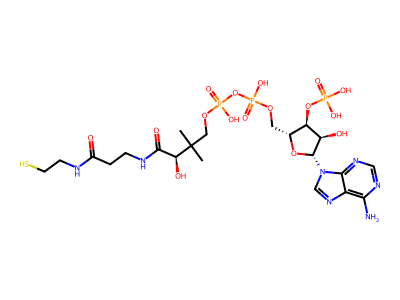

In [11]:
mol = Chem.MolFromSmiles(topTarget)

if mol is None:
    print("Invalid SMILES for topTarget:", topTarget)
else:
    # Draw single molecule
    img = Draw.MolToImage(mol, size=(400, 300))
    display(img)

### Investigate reactions that reached atleast `any starter --> one target`

### Keep only enzymatic DORAnet reactions

In [12]:
enzymaticReactionDF = reactionDF_wTarget_mostPathways[
    reactionDF["reactionType"].astype(str).str.lower().str.contains(
        "enzyme|enzymatic|bio|biological",
        na=False
    )
].copy()

print(f"Total reactions: {len(reactionDF):,}")
print(f"Likely enzymatic reactions: {len(enzymaticReactionDF):,}")

enzymaticReactionDF.head()

Total reactions: 176,400
Likely enzymatic reactions: 60


/tmp/ipykernel_1754083/4093279067.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  enzymaticReactionDF = reactionDF_wTarget_mostPathways[


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical
3389,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...
5977,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...
8127,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cn...
8966,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...
11229,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...


## 2. Use `DORA-XGB` to get feasibility score

In [13]:
reactionDF_DORAXGB = enzymaticReactionDF.copy()
#reactionDF_DORAXGB = enzymaticReactionDF.head(50).copy()

# Clean reaction string for model input
reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

def getFeasibilityScoresAndLabels(rxnStr):
    return pd.Series({
        "feasibilityScore_rule1": by_desc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule1": by_desc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule2": by_asc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule2": by_asc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule3": add_concat_model.predict_proba(rxnStr),
        "feasibilityLabel_rule3": add_concat_model.predict_label(rxnStr),

        "feasibilityScore_rule4": add_subtract_model.predict_proba(rxnStr),
        "feasibilityLabel_rule4": add_subtract_model.predict_label(rxnStr),
    })


reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

reactionDF_DORAXGB[
    [
        "feasibilityScore_rule1",
        "feasibilityLabel_rule1",
        "feasibilityScore_rule2",
        "feasibilityLabel_rule2",
        "feasibilityScore_rule3",
        "feasibilityLabel_rule3",
        "feasibilityScore_rule4",
        "feasibilityLabel_rule4",
    ]
] = reactionDF_DORAXGB["rxn_str"].apply(getFeasibilityScoresAndLabels)

reactionDF_DORAXGB.head()

,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
3389,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.000065,0.0,0.044277,0.0,0.096092,0.0,0.014657,0.0
5977,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.331770,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
8127,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cnc...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.000091,0.0,0.023566,0.0,0.133011,0.0,0.742495,1.0
8966,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.331770,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
11229,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.000065,0.0,0.044277,0.0,0.096092,0.0,0.014657,0.0


### Keep only `high feasible` reactions

In [14]:
# Choose which feasibility label to use
feasibilityLabel = "feasibilityLabel_rule2"   # <- change to rule2/rule3/rule4 as needed
targetValue = 1                               # <- change if you want a different label value

# Optional safety check
validLabels = [
    "feasibilityLabel_rule1",
    "feasibilityLabel_rule2",
    "feasibilityLabel_rule3",
    "feasibilityLabel_rule4",
]
if feasibilityLabel not in validLabels:
    raise ValueError(f"Invalid feasibilityLabel: {feasibilityLabel}. Choose from {validLabels}")

if feasibilityLabel not in reactionDF_DORAXGB.columns:
    raise KeyError(f"Column '{feasibilityLabel}' not found in reactionDF_DORAXGB")

In [15]:
reactionDF_DORAXGB_highFeasibility = (
    reactionDF_DORAXGB[
        (reactionDF_DORAXGB[feasibilityLabel] == targetValue)
        & (reactionDF_DORAXGB[feasibilityLabel].notna())
    ]
    .sort_values(by=feasibilityLabel, ascending=False)
    .reset_index(drop=True)
)

uniqueReactantStrings_high = set(reactionDF_DORAXGB_highFeasibility["reactants"])
uniqueProductStrings_high = set(reactionDF_DORAXGB_highFeasibility["products"])

uniqueReactantMolecules_high = {
    mol.strip()
    for reactants in reactionDF_DORAXGB_highFeasibility["reactants"]
    for mol in str(reactants).split(".")
    if mol.strip()
}

uniqueProductMolecules_high = {
    mol.strip()
    for products in reactionDF_DORAXGB_highFeasibility["products"]
    for mol in str(products).split(".")
    if mol.strip()
}

print(f"Feasibility label used: {feasibilityLabel} == {targetValue}")
print(f"Number of high-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility)}")
print(f"Number of unique reactant strings: {len(uniqueReactantStrings_high)}")
print(f"Number of unique product strings: {len(uniqueProductStrings_high)}")
print(f"Number of unique individual reactant molecules: {len(uniqueReactantMolecules_high)}")
print(f"Number of unique individual product molecules: {len(uniqueProductMolecules_high)}")

# reactionDF_DORAXGB_highFeasibility.to_csv(os.path.join(DNADesignResultsDir, f"DORAXGB_highFeasibility_{feasibilityLabel}.csv"),index=False)
reactionDF_DORAXGB_highFeasibility.head()

Feasibility label used: feasibilityLabel_rule2 == 1
Number of high-feasibility reactions: 20
Number of unique reactant strings: 1
Number of unique product strings: 1
Number of unique individual reactant molecules: 2
Number of unique individual product molecules: 2


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0


### Summarize unique DORAnet rules

Many reactions may use the same rule. We do not want to annotate millions of reactions one by one. First annotate the rules.

In [16]:
enzymaticReactionDF = reactionDF_DORAXGB_highFeasibility.copy()
ruleSummaryDF = (
    enzymaticReactionDF
    .groupby(["ruleName", "reactionType"], dropna=False)
    .agg(
        numReactions=("reactionString", "count"),
        #numStarterSources=("sourceFolderNum", "nunique"),
        exampleReaction=("reactionString", "first"),
        exampleReactants=("reactants", "first"),
        exampleProducts=("products", "first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)

print(f"unique DORAnet rules    : {enzymaticReactionDF['ruleName'].nunique():,}")
ruleSummaryDF

unique DORAnet rules    : 1


,ruleName,reactionType,numReactions,exampleReaction,exampleReactants,exampleProducts
0,rule0062_18,Enzymatic,20,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...


### Add required placeholder columns

In [17]:
enzymeAnnotationDF = ruleSummaryDF.copy()

enzymeAnnotationDF["suggestedEnzymeClass"] = ""
enzymeAnnotationDF["ecNumber"] = ""
enzymeAnnotationDF["enzymeName"] = ""
enzymeAnnotationDF["uniprotAccession"] = ""
enzymeAnnotationDF["sourceDatabase"] = ""
enzymeAnnotationDF["reactionSimilarity"] = ""
enzymeAnnotationDF["enzymeConfidence"] = ""
enzymeAnnotationDF["notes"] = ""
enzymeAnnotationDF.head()

,ruleName,reactionType,numReactions,exampleReaction,exampleReactants,exampleProducts,suggestedEnzymeClass,ecNumber,enzymeName,uniprotAccession,sourceDatabase,reactionSimilarity,enzymeConfidence,notes
0,rule0062_18,Enzymatic,20,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,,,,,,,,


## 3. Read DORAnet reaction ruleset file to extract `UniProt ID` for each `reaction rule`

In [18]:
doranetRulesetDF = pd.read_csv(dataDir + "/DORAnet/JN3604IMT_rules.tsv", sep="\t")

print(doranetRulesetDF.shape)
print(doranetRulesetDF.columns.tolist())
doranetRulesetDF.head()

(3604, 5)
['Name', 'Reactants', 'SMARTS', 'Products', 'Comments']


,Name,Reactants,SMARTS,Products,Comments
0,rule0001_01,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,P97259;P97402;Q08834;Q09328;Q16408;Q3V5L5;Q765...
1,rule0001_02,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,A0K8D0;A0KHH6;A0KZ10;A0L8R9;A0Q7X9;A1A7M6;A1K6...
2,rule0001_03,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,P0DMP6;P0DMP7;P16442;Q15951;Q1RLK6;Q3USF0;Q5HZ...
3,rule0001_04,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,A4IID1;O19071;O77836;P23336;P26572;P27115;P278...
4,rule0001_05,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,NaN


### Find the number of common reaction rules between `DORAnet` diversification and ruleset table from actual package

In [19]:
reactionRuleSet = set(reactionDF_DORAXGB_highFeasibility["ruleName"].dropna().astype(str).str.strip())
tsvRuleSet = set(doranetRulesetDF["Name"].dropna().astype(str).str.strip())

matchedRuleSet = reactionRuleSet.intersection(tsvRuleSet)
missingRuleSet = reactionRuleSet.difference(tsvRuleSet)

print(f"Rules present in DORAnet diversification run: {len(reactionRuleSet):,}")
print(f"Rules matched from DORAnet package: {len(matchedRuleSet):,}")
print(f"Rules missing from DORAnet package: {len(missingRuleSet):,}")

print("\nMatched rules:")
print(sorted(list(matchedRuleSet))[:20])

print("\nMissing rules:")
print(sorted(list(missingRuleSet))[:20])

Rules present in DORAnet diversification run: 1
Rules matched from DORAnet package: 1
Rules missing from DORAnet package: 0

Matched rules:
['rule0062_18']

Missing rules:
[]


### Extract `UniProt IDs` from `DORAnet` reaction rules

In [20]:
def splitUniProtIds(idString):
    if pd.isna(idString):
        return []
    return [x.strip() for x in str(idString).split(";") if x.strip()]


ruleInfoDF = doranetRulesetDF.copy()

ruleInfoDF = ruleInfoDF.rename(columns={
    "Name": "ruleName",
    "Reactants": "ruleReactants",
    "SMARTS": "ruleSMARTS",
    "Products": "ruleProducts",
    "Comments": "candidateUniProtRaw",
})

ruleInfoDF["ruleName"] = ruleInfoDF["ruleName"].astype(str).str.strip()
ruleInfoDF["candidateUniProtList"] = ruleInfoDF["candidateUniProtRaw"].apply(splitUniProtIds)
ruleInfoDF["numCandidateUniProt"] = ruleInfoDF["candidateUniProtList"].apply(len)

ruleInfoDF = ruleInfoDF[
    [
        "ruleName",
        "ruleReactants",
        "ruleProducts",
        "ruleSMARTS",
        "candidateUniProtRaw",
        "numCandidateUniProt",
    ]
].copy()



print(f"ruleInfoDF rows: {len(ruleInfoDF):,}")
ruleInfoDF

ruleInfoDF rows: 3,604


,ruleName,ruleReactants,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt
0,rule0001_01,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,P97259;P97402;Q08834;Q09328;Q16408;Q3V5L5;Q765...,10
1,rule0001_02,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,A0K8D0;A0KHH6;A0KZ10;A0L8R9;A0Q7X9;A1A7M6;A1K6...,263
2,rule0001_03,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,P0DMP6;P0DMP7;P16442;Q15951;Q1RLK6;Q3USF0;Q5HZ...,29
3,rule0001_04,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,A4IID1;O19071;O77836;P23336;P26572;P27115;P278...,42
4,rule0001_05,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,NaN,0
...,...,...,...,...,...,...
3599,rule1152_1,Any;Any,Any;Any,[#6;$([#6&R]1-&@[#8&R]-&@[#6&R]-&@[#6&R](-&@[#...,Q8ZUN8,1
3600,rule1152_2,Any;Any,Any;Any,[#6;!$([#6&R]1-&@[#8&R]-&@[#6&R]-&@[#6&R](-&@[...,B9TTF1,1
3601,rule1164_1,Any;WATER,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1:&@[#6&R]:&@[#6&R]:&@[...,Q972I2,1
3602,rule1165_1,Any;H2O2,Any;WATER,[#6;$([#6&!R]-[#6&R]1:&@[#6&R]:&@[#6&R]:&@[#6&...,Q972I2,1


## 4. Merge rule information into `reactionDF`

This connects DORAnet reactions with the rule SMARTS and UniProt candidate list.

In [21]:
reactionDF_wUniprotID = reactionDF_DORAXGB_highFeasibility.merge(ruleInfoDF,on="ruleName",how="left")

reactionDF_wUniprotID["hasRuleLookup"] = reactionDF_wUniprotID["ruleSMARTS"].notna()

print(reactionDF_wUniprotID["hasRuleLookup"].value_counts(dropna=False))
reactionDF_wUniprotID

hasRuleLookup
True    20
Name: count, dtype: int64


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical,rxn_str,feasibilityScore_rule1,...,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4,ruleReactants,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
5,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway14,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
6,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway15,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.992998,1.0,0.990675,1.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True
7,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway16,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C

## 4. Find best `UniProt ID` per rule by `Reaction Center Morgan Fingerprint (RCMFP)` enzyme retrieval similarity search 

Implements workflow from the DORAnet/DORA-XGB → atom mapping → RCMFP → known enzyme retrieval. It uses `ruleBase` as the practical bridge between expanded DORAnet rule names such as `rule0003_170` and known reference coarse operator IDs such as `rule0003`, then ranks candidate natural enzyme precedents by RCMFP Tanimoto similarity.

Use this tool: https://github.com/stefanpate/ergochemics/tree/main#

### Patch `RDKit/ergochemics` compatibility

This preserves atom-map labels. Do not use a patch that clears atom-map numbers, because RCMFP needs atom maps to infer reaction centers.

In [22]:
# User paths
ERGOCHEMICS_SRC = "/users/sghosh6/DTRA_project/MACAW/ergochemics/src"
if ERGOCHEMICS_SRC not in sys.path: sys.path.insert(0, ERGOCHEMICS_SRC)

import ergochemics.mapping as egmap
import ergochemics.similarity as egsim
print("RDKit version:", rdBase.rdkitVersion); print("ergochemics mapping file:", egmap.__file__)

_RDKit_MolToSmiles_original = rdmolfiles.MolToSmiles

def MolToSmiles_compat(mol, *args, **kwargs):
    kwargs.pop("ignoreAtomMapNumbers", None)
    return _RDKit_MolToSmiles_original(mol, *args, **kwargs)

Chem.MolToSmiles = MolToSmiles_compat; egmap.Chem.MolToSmiles = MolToSmiles_compat; egsim.Chem.MolToSmiles = MolToSmiles_compat
operator_map_reaction, get_reaction_center = egmap.operator_map_reaction, egmap.get_reaction_center
ReactionFingerprinter, MolFeaturizer = egsim.ReactionFingerprinter, egsim.MolFeaturizer
print("Patch test:", Chem.MolToSmiles(Chem.MolFromSmiles("[CH3:1][OH:2]"), ignoreAtomMapNumbers=True))

RDKit version: 2023.09.5
ergochemics mapping file: /users/sghosh6/DTRA_project/MACAW/ergochemics/src/ergochemics/mapping.py
Patch test: [CH3:1][OH:2]


### Normalize DORAnet reaction strings and `atom-map` all reactions

In [23]:
def normalize_reaction_string(rxn):
    if pd.isna(rxn): return None
    rxn = str(rxn).strip().replace(" ", "")
    if rxn.count(">") == 2 and ">>" in rxn: return rxn
    parts = rxn.split(">")
    return f"{parts[0]}>>{parts[2]}" if len(parts) == 3 else None

def map_query_reaction_with_rule(row):
    rxn, ruleSMARTS = row.get("queryReaction"), row.get("ruleSMARTS")
    if pd.isna(rxn) or str(rxn).strip() == "": return None, "missing_queryReaction"
    if pd.isna(ruleSMARTS) or str(ruleSMARTS).strip() == "": return None, "missing_ruleSMARTS"
    rxn, ruleSMARTS, lastError = str(rxn).replace(" ", ""), str(ruleSMARTS).strip(), None
    if ">>" not in rxn: return None, "invalid_queryReaction_no_double_arrow"
    if ">>" not in ruleSMARTS: return None, "invalid_ruleSMARTS_no_double_arrow"
    for explicitHsFlag, statusLabel in [(False, "mapped"), (True, "mapped_explicit_h")]:
        try:
            result = operator_map_reaction(rxn=rxn, operator=ruleSMARTS, explicit_hs=explicitHsFlag, quiet=True)
            if result.did_map and result.atom_mapped_smarts is not None: return result.atom_mapped_smarts, statusLabel
            lastError = f"{statusLabel}_failed"
        except Exception as exc: lastError = f"mapping_error:{type(exc).__name__}:{exc}"
    return None, lastError

AtomMapDF = reactionDF_wUniprotID.copy()
AtomMapDF["queryReaction"] = AtomMapDF["reactionString"].apply(normalize_reaction_string)
AtomMapDF = AtomMapDF[AtomMapDF["queryReaction"].notna() & AtomMapDF["ruleSMARTS"].notna()].drop(columns=["queryMappedReaction", "rcmfpMappingStatus"], errors="ignore").copy()

mappedPairs = AtomMapDF.progress_apply(map_query_reaction_with_rule, axis=1)
AtomMapDF[["queryMappedReaction", "rcmfpMappingStatus"]] = pd.DataFrame(mappedPairs.tolist(), index=AtomMapDF.index)
sucessAtomMapDF = AtomMapDF[AtomMapDF["queryMappedReaction"].notna()].copy() 
failedAtomMapDF = AtomMapDF[AtomMapDF["queryMappedReaction"].isna()].copy()
print(AtomMapDF["rcmfpMappingStatus"].value_counts(dropna=False))
print("Successful atom mapping:", len(sucessAtomMapDF), "| Failed:", len(failedAtomMapDF))
sucessAtomMapDF.shape

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 239.74it/s]

rcmfpMappingStatus
mapped    20
Name: count, dtype: int64
Successful atom mapping: 20 | Failed: 0


(20, 26)

### Compute `RCMFP fingerprints`

In [24]:
TOP_K, MIN_SIMILARITY, FP_SIDE_LENGTH, FP_RADIUS = 20, 0.0, 2048, 2

In [25]:
reactionFingerprinter = ReactionFingerprinter(radius=FP_RADIUS, length=FP_SIDE_LENGTH, mol_featurizer=MolFeaturizer())

def compute_rcmfp_with_status(mappedRxn):
    try:
        if pd.isna(mappedRxn) or str(mappedRxn).strip() == "": return None, "missing_mapped_reaction"
        mappedRxn = str(mappedRxn).replace(" ", "")
        if ">>" not in mappedRxn: return None, "invalid_mapped_reaction_no_double_arrow"
        if not pd.Series([mappedRxn]).str.contains(r":\d+\]", regex=True).iloc[0]: return None, "no_atom_map_labels"
        lrc, rrc = get_reaction_center(mappedRxn, mode="combined")
        if len(lrc) == 0 or len(rrc) == 0: return None, f"empty_reaction_center:lrc={len(lrc)}:rrc={len(rrc)}"
        fp = reactionFingerprinter.fingerprint(mappedRxn, output_type="bit", use_rc=True, rc_dist_ub=None)
        return fp.astype(bool), "rcmfp_success"
    except Exception as exc: return None, f"rcmfp_error:{type(exc).__name__}:{exc}"


rcmfpPairs = sucessAtomMapDF["queryMappedReaction"].progress_apply(compute_rcmfp_with_status)
sucessAtomMapDF[["queryRCMFP", "rcmfpStatus"]] = pd.DataFrame(rcmfpPairs.tolist(), index=sucessAtomMapDF.index)
queryRcmfpFailureDF = sucessAtomMapDF[sucessAtomMapDF["queryRCMFP"].isna()].copy()
sucessAtomMapDF = sucessAtomMapDF[sucessAtomMapDF["queryRCMFP"].notna()].copy().reset_index(drop=True)
sucessAtomMapDF

  0%|                                                                                                               | 0/20 [00:00<?, ?it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 55, 53: 57, 54: 60, 55: 62, 56: 64, 57: 66, 58: 63, 59: 65, 60: 67, 61: 69, 62: 68, 63: 70, 64: 59, 65: 61, 66: 56, 67: 58, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 52, 66, 53, 67, 64, 54, 65, 55, 58, 56, 59, 57, 60, 62, 61, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

 20%|████████████████████▌                                                                                  | 4/20 [00:00<00:00, 27.03it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 55, 53: 57, 54: 60, 55: 62, 56: 64, 57: 66, 58: 63, 59: 65, 60: 67, 61: 69, 62: 68, 63: 70, 64: 59, 65: 61, 66: 56, 67: 58, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 52, 66, 53, 67, 64, 54, 65, 55, 58, 56, 59, 57, 60, 62, 61, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

 35%|████████████████████████████████████                                                                   | 7/20 [00:00<00:00, 22.97it/s]

...

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 55, 53: 57, 54: 60, 55: 62, 56: 64, 57: 66, 58: 63, 59: 65, 60: 67, 61: 69, 62: 68, 63: 70, 64: 59, 65: 61, 66: 56, 67: 58, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 52, 66, 53, 67, 64, 54, 65, 55, 58, 56, 59, 57, 60, 62, 61, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

 95%|████████████████████████████████████████████████████████████████████████████████████████████████▉     | 19/20 [00:00<00:00, 20.57it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 55, 53: 57, 54: 60, 55: 62, 56: 64, 57: 66, 58: 63, 59: 65, 60: 67, 61: 69, 62: 68, 63: 70, 64: 59, 65: 61, 66: 56, 67: 58, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 52, 66, 53, 67, 64, 54, 65, 55, 58, 56, 59, 57, 60, 62, 61, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 20.15it/s]


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical,rxn_str,feasibilityScore_rule1,...,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup,queryReaction,queryMappedReaction,rcmfpMappingStatus,queryRCMFP,rcmfpStatus
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
5,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway14,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,CoA;Any,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[False, False, False, False, False, F

In [26]:
print("RCMFP status counts:")
print(sucessAtomMapDF["rcmfpStatus"].value_counts(dropna=False))
print("Valid RCMFP reactions:", len(sucessAtomMapDF))
print("Failed RCMFP reactions:", len(queryRcmfpFailureDF))

RCMFP status counts:
rcmfpStatus
rcmfp_success    20
Name: count, dtype: int64
Valid RCMFP reactions: 20
Failed RCMFP reactions: 0


### Load and align known enzyme reference metadata and RCMFP cache

- loaded from: https://github.com/JBEI/TridentSynthWeb/tree/b17e61040b182ce68b2931f8dbbaf65f370f8c03/data/processed

In [27]:
naturalEnzymeFilePath = os.path.join(dataDir + "/DORAnet/known_enzyme_reactions_union.parquet")
naturalEnzyme_FP_FilePath = os.path.join(dataDir + "/DORAnet/known_rxn_rcmfp_cache.npz")

naturalEnzymeDF = pd.read_parquet(naturalEnzymeFilePath)
naturalEnzymeDF_wFingerprints = np.load(naturalEnzyme_FP_FilePath, allow_pickle=True)
naturalEnzyme_fingerprint_matrix = naturalEnzymeDF_wFingerprints["fingerprints"].astype(bool)
naturalEnzyme_RC_PatternLHS, naturalEnzyme_RC_PatternRHS, knownValidIndices = naturalEnzymeDF_wFingerprints["rc_patterns_lhs"], naturalEnzymeDF_wFingerprints["rc_patterns_rhs"], naturalEnzymeDF_wFingerprints["valid_indices"]
naturalEnzymeReferenceDF = naturalEnzymeDF.iloc[knownValidIndices].reset_index(drop=True).copy()
naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternLHS"], naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternRHS"], naturalEnzymeReferenceDF["knownOriginalIndex"] = naturalEnzyme_RC_PatternLHS, naturalEnzyme_RC_PatternRHS, knownValidIndices
assert len(naturalEnzymeReferenceDF) == naturalEnzyme_fingerprint_matrix.shape[0]
print("Known enzyme reference shape:", naturalEnzymeReferenceDF.shape); print("Known enzyme molecular fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)

Known enzyme reference shape: (54063, 25)
Known enzyme molecular fingerprint matrix shape: (54063, 4096)


### Compute RCMFP fingerprint matrices for `DORAnet` reactions

In [28]:
def make_reverse_fingerprint_matrix(fpMatrix, sideLength=FP_SIDE_LENGTH): return np.hstack([fpMatrix[:, sideLength:], fpMatrix[:, :sideLength]]).astype(bool)
def make_fingerprint_matrix_from_column(df, fpCol):
    validMask = df[fpCol].notna(); metaDF = df.loc[validMask].drop(columns=[fpCol], errors="ignore").reset_index(drop=True)
    fpMatrix = np.vstack(df.loc[validMask, fpCol].to_numpy()).astype(bool); fpReverseMatrix = make_reverse_fingerprint_matrix(fpMatrix)
    return metaDF, fpMatrix, fpReverseMatrix, fpMatrix.sum(axis=1), fpReverseMatrix.sum(axis=1)

queryMetaDF, query_FP_Matrix, query_FP_MatrixReverse, queryPopcounts, queryReversePopcounts = make_fingerprint_matrix_from_column(sucessAtomMapDF, "queryRCMFP")
naturalEnzyme_fingerprint_matrixReverse = make_reverse_fingerprint_matrix(naturalEnzyme_fingerprint_matrix)
knownPopcounts, knownReversePopcounts = naturalEnzyme_fingerprint_matrix.sum(axis=1), naturalEnzyme_fingerprint_matrixReverse.sum(axis=1)

queryKeepCols = ["reactants", "products", "reactionString", "ruleName", "reactionType", "rxn_str", "ruleSMARTS", "candidateUniProtRaw", "numCandidateUniProt", "hasRuleLookup", "queryReaction", "queryMappedReaction", "rcmfpMappingStatus", "rcmfpStatus", "feasibilityScore_rule1", "feasibilityLabel_rule1", "feasibilityScore_rule2", "feasibilityLabel_rule2", "feasibilityScore_rule3", "feasibilityLabel_rule3", "feasibilityScore_rule4", "feasibilityLabel_rule4"]
queryMetaDF = queryMetaDF[[c for c in queryKeepCols if c in queryMetaDF.columns]].copy()
print("Query metadata shape:", queryMetaDF.shape); print("Query molecular fingerprint matrix shape:", query_FP_Matrix.shape); print("Known enzyme molecular fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)
queryMetaDF

Query metadata shape: (20, 22)
Query molecular fingerprint matrix shape: (20, 4096)
Known enzyme molecular fingerprint matrix shape: (54063, 4096)


,reactants,products,reactionString,ruleName,reactionType,rxn_str,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup,...,rcmfpMappingStatus,rcmfpStatus,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
5,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
6,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
7,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
8,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_success,0.33177,0.0,0.991104,1.0,0.992998,1.0,0.990675,1.0
9,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#8;$([#8&!R]-[#6&!R]);!$([#8&!...,G1EFQ3;Q00857,2,True,...,mapped,rcmfp_

### Add `ruleBase` column to known enzyme reference and query metadata from DORAnet reactions

This avoids forcing known reference rules into expanded DORAnet rule names. It uses coarse operator family IDs such as `rule0003` and then lets RCMFP decide the closest natural reaction within that family.

In [29]:
def get_rule_base(x): return None if pd.isna(x) else str(x).strip().split("_")[0]
def parse_operator_list(x):
    if isinstance(x, np.ndarray): return [str(v).strip() for v in x.tolist() if v is not None and str(v).strip()]
    if isinstance(x, (list, tuple, set)): return [str(v).strip() for v in list(x) if v is not None and str(v).strip()]
    if x is None or pd.isna(x): return []
    s = str(x).strip()
    if s in ["", "nan", "None", "[]"]: return []
    try:
        parsed = ast.literal_eval(s)
        return [str(v).strip() for v in list(parsed)] if isinstance(parsed, (list, tuple, set, np.ndarray)) else [str(parsed).strip()]
    except Exception:
        for sep in ["|", ";", ","]:
            if sep in s: return [v.strip().strip("'\"") for v in s.split(sep) if v.strip()]
        return [s]

def choose_known_rule_base(row):
    top = row.get("top_mapped_operator")
    if top is not None and not pd.isna(top) and str(top).strip().startswith("rule"): return str(top).strip(), "top_mapped_operator"
    for op in parse_operator_list(row.get("all_mapped_operators")):
        if str(op).startswith("rule"): return str(op), "all_mapped_operators"
    return None, "no_ruleBase"



# Build ruleBase in naturalEnzymeReferenceDF
naturalEnzymeReferenceDF = naturalEnzymeReferenceDF.copy()

naturalEnzymeReferenceDF[["ruleBase", "ruleBaseSource"]] = naturalEnzymeReferenceDF.apply(
    lambda row: pd.Series(choose_known_rule_base(row)),
    axis=1
)

# If you want only base (e.g., rule0001 from rule0001_22), normalize:
naturalEnzymeReferenceDF["ruleBase"] = naturalEnzymeReferenceDF["ruleBase"].apply(get_rule_base)

# Rebuild metadata
queryMetaDF = queryMetaDF.reset_index(drop=True).copy()
knownMetaDF = naturalEnzymeReferenceDF.reset_index(drop=True).copy()

queryMetaDF["queryRowId"] = np.arange(len(queryMetaDF))
knownMetaDF["knownRowId"] = np.arange(len(knownMetaDF))

queryMetaDF["ruleBase"] = queryMetaDF["ruleName"].apply(get_rule_base)

queryMetaDF["_ruleKey"] = queryMetaDF["ruleBase"].astype("object")
knownMetaDF["_ruleKey"] = knownMetaDF["ruleBase"].astype("object")

# Create ruleBase first, then use it
queryMetaDF["ruleBase"] = queryMetaDF["ruleName"].apply(get_rule_base)

if "ruleBase" not in knownMetaDF.columns:
    raise KeyError("knownMetaDF does not contain ruleBase after merge. Check knownOriginalIndex alignment.")

queryMetaDF["_ruleKey"] = queryMetaDF["ruleBase"].astype("object")
knownMetaDF["_ruleKey"] = knownMetaDF["ruleBase"].astype("object")

knownIndicesByRuleBase = {
    ruleBase: idx.to_numpy()
    for ruleBase, idx in knownMetaDF.dropna(subset=["_ruleKey"]).groupby("_ruleKey").groups.items()
}

queryRuleBases = set(queryMetaDF["ruleBase"].dropna().astype(str))
knownRuleBases = set(knownMetaDF["ruleBase"].dropna().astype(str))

print("Source of known enzymetic data base:")
print(knownMetaDF["ruleBaseSource"].value_counts(dropna=False))
print("Reaction rules present in DORAnet reaction mechanism:", len(queryRuleBases))
print("Reaction rules present in known enzymetic data base:", len(knownRuleBases))
print("Overlapping base reaction rules:", len(queryRuleBases.intersection(knownRuleBases)))
print("Example overlaps:", sorted(queryRuleBases.intersection(knownRuleBases))[:20])

Source of known enzymetic data base:
ruleBaseSource
top_mapped_operator     45763
all_mapped_operators     6882
no_ruleBase              1418
Name: count, dtype: int64
Reaction rules present in DORAnet reaction mechanism: 1
Reaction rules present in known enzymetic data base: 687
Overlapping base reaction rules: 1
Example overlaps: ['rule0062']


### Run `ruleBase` constrained RCMFP enzyme retrieval

For each query reaction (present in DORAnet reaction network) it searches the known natural enzyme reaction database, computes RCMFP Tanimoto similarity, keeps the best matches and stores the results in `matchedRCMFP_DF`. Final returned matches are ranked from highest to lowest RCMFP similarity.

In [30]:
# this function calculates Tanimoto similarity between one query fingerprint and many known enzyme reference fingerprints
def compute_tanimoto_similarity(queryPackedRow, queryPop, refPackedMatrix, refPopcounts, popcount8):
    inter = popcount8[np.bitwise_and(refPackedMatrix, queryPackedRow)].sum(axis=1).astype(np.float32); union = refPopcounts + queryPop - inter
    scores = np.zeros(len(refPopcounts), dtype=np.float32); valid = union > 0; scores[valid] = inter[valid] / union[valid]
    return scores

# this function retrieves the top enzyme reference matches for one query reaction
def retrieve_similar_reactions(queryIdx, topK=TOP_K, minSimilarity=MIN_SIMILARITY):
    queryRuleBase = queryMetaDF.loc[queryIdx, "_ruleKey"]
    candidateIdx, searchMode = (knownIndicesByRuleBase[queryRuleBase], "same_ruleBase") if pd.notna(queryRuleBase) and queryRuleBase in knownIndicesByRuleBase else (np.arange(len(knownMetaDF)), "full_database_fallback")
    qPacked, qPop = queryPacked[queryIdx], queryPopcounts[queryIdx]
    scores = np.maximum(compute_tanimoto_similarity(qPacked, qPop, knownPacked[candidateIdx], knownPopcounts[candidateIdx], popcount8), compute_tanimoto_similarity(qPacked, qPop, knownPackedReverse[candidateIdx], knownReversePopcounts[candidateIdx], popcount8))
    validLocal = np.where(scores > minSimilarity)[0]
    if len(validLocal) == 0: return []
    topLocal = validLocal[np.argpartition(-scores[validLocal], topK - 1)[:topK]] if len(validLocal) > topK else validLocal
    topLocal = topLocal[np.argsort(-scores[topLocal])]
    return [{"queryRowId": int(queryIdx), "rank": rank, "knownRowId": int(candidateIdx[localIdx]), "rcmfpSimilarity": float(scores[localIdx]), "searchMode": searchMode, "numCandidatesSearched": int(len(candidateIdx))} for rank, localIdx in enumerate(topLocal, start=1)]

query_FP_Matrix, naturalEnzyme_fingerprint_matrix, naturalEnzyme_fingerprint_matrixReverse = query_FP_Matrix.astype(bool), naturalEnzyme_fingerprint_matrix.astype(bool), naturalEnzyme_fingerprint_matrixReverse.astype(bool)
queryPacked, knownPacked, knownPackedReverse = np.packbits(query_FP_Matrix.astype(np.uint8), axis=1), np.packbits(naturalEnzyme_fingerprint_matrix.astype(np.uint8), axis=1), np.packbits(naturalEnzyme_fingerprint_matrixReverse.astype(np.uint8), axis=1)
queryPopcounts, knownPopcounts, knownReversePopcounts = query_FP_Matrix.sum(axis=1).astype(np.int32), naturalEnzyme_fingerprint_matrix.sum(axis=1).astype(np.int32), naturalEnzyme_fingerprint_matrixReverse.sum(axis=1).astype(np.int32)
popcount8 = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)

allHitRecords = []
for queryIdx in tqdm(range(len(queryMetaDF)), desc="RCMFP enzyme retrieval"): allHitRecords.extend(retrieve_similar_reactions(queryIdx))
matchedRCMFP_DF = pd.DataFrame(allHitRecords)
print("Total hits:", len(matchedRCMFP_DF)); print(matchedRCMFP_DF["searchMode"].value_counts(dropna=False))
matchedRCMFP_DF.head()

RCMFP enzyme retrieval: 100%|█████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 853.41it/s]

Total hits: 400
searchMode
same_ruleBase    400
Name: count, dtype: int64


,queryRowId,rank,knownRowId,rcmfpSimilarity,searchMode,numCandidatesSearched
0,0,1,12665,0.132565,same_ruleBase,283
1,0,2,12550,0.132565,same_ruleBase,283
2,0,3,12579,0.132565,same_ruleBase,283
3,0,4,12580,0.132565,same_ruleBase,283
4,0,5,12581,0.132565,same_ruleBase,283


### Build full summary, filter Moderate/Strong, deduplicate and save outputs

In [31]:
def print_section(title):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)

def print_saved_file(label, path):
    print(f"{label}: {path}")

def classify_precedent(sim):
    if pd.isna(sim): return "No natural precedent retrieved"
    if sim >= 0.60: return "Strong natural enzyme precedent"
    if sim >= 0.35: return "Moderate natural enzyme precedent"
    if sim > 0: return "Weak precedent; likely enzyme-engineering risk"
    return "No useful RCMFP precedent"

queryDisplayCols = [c for c in ["queryRowId", "reactionString", "ruleName", "ruleBase", "reactionType", "queryReaction", "queryMappedReaction", "candidateUniProtRaw", "numCandidateUniProt", "rcmfpMappingStatus", "rcmfpStatus", "feasibilityScore_rule1", "feasibilityLabel_rule1", "feasibilityScore_rule2", "feasibilityLabel_rule2", "feasibilityScore_rule3", "feasibilityLabel_rule3", "feasibilityScore_rule4", "feasibilityLabel_rule4"] if c in queryMetaDF.columns]
knownDisplayCols = [c for c in ["knownRowId", "knownOriginalIndex", "ruleBase", "ruleBaseSource", "rxn_idx", "mapped", "unmapped", "orig_rxn_text", "rule", "source", "quality", "natural", "organism", "protein_refs", "protein_db", "ec_num", "top_mapped_operator", "all_mapped_operators"] if c in knownMetaDF.columns]

matchedRCMFP_DF = matchedRCMFP_DF.merge(queryMetaDF[queryDisplayCols], on="queryRowId", how="left", suffixes=("", "_query")).merge(knownMetaDF[knownDisplayCols], on="knownRowId", how="left", suffixes=("", "_known")).sort_values(["queryRowId", "rank"]).reset_index(drop=True)
matchedRCMFP_DF.head()

,queryRowId,rank,knownRowId,rcmfpSimilarity,searchMode,numCandidatesSearched,reactionString,ruleName,ruleBase,reactionType,...,rule,source,quality,natural,organism,protein_refs,protein_db,ec_num,top_mapped_operator,all_mapped_operators
0,0,1,12665,0.132565,same_ruleBase,283,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,rule0062,Enzymatic,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,0.009479,0.0,Enterococcus sp.,[],None,2.3.1.82,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
1,0,2,12550,0.132565,same_ruleBase,283,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,rule0062,Enzymatic,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,0.960000,0.0,Escherichia coli,[],None,2.3.1.79,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
2,0,3,12579,0.132565,same_ruleBase,283,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,rule0062,Enzymatic,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,0.960000,0.0,Escherichia coli,['P77791'],uniprot,2.3.1.79,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
3,0,4,12580,0.132565,same_ruleBase,283,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,rule0062,Enzymatic,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,0.960000,0.0,Escherichia coli,['P77791'],uniprot,2.3.1.79,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
4,0,5,12581,0.132565,same_ruleBase,283,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,rule0062,Enzymatic,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,0.960000,0.0,Escherichia coli,['P77791'],uniprot,2.3.1.79,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."


### Marge information of natural enzyme reference to `reactionDF_wUniprotID`

In [32]:
# User options
keyCol = "reactionString"
scoreCol = "rcmfpSimilarity"
keepMode = "best"   # "best" or "all"
bestAscending = False  # False => highest score is best, True => lowest is best

sourceDF = matchedRCMFP_DF.copy()

if keepMode == "best":
    sourceToMerge = (
        sourceDF
        .sort_values(scoreCol, ascending=bestAscending, na_position="last")
        .drop_duplicates(subset=[keyCol], keep="first")
    )
elif keepMode == "all":
    sourceToMerge = sourceDF
else:
    raise ValueError("keepMode must be 'best' or 'all'")

# only add columns that don't already exist in target
newCols = [c for c in sourceToMerge.columns if c not in reactionDF_wUniprotID.columns and c != keyCol]

reactionDF_wUniprotID = reactionDF_wUniprotID.merge(
    sourceToMerge[[keyCol] + newCols],
    on=keyCol,
    how="inner"   # keep only rows present in source
)

print(f"Mode: {keepMode}")
print(f"Rows after merge: {len(reactionDF_wUniprotID):,}")
print(f"Added columns: {len(newCols)}")
reactionDF_wUniprotID

Mode: best
Rows after merge: 20
Added columns: 28


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical,rxn_str,feasibilityScore_rule1,...,rule,source,quality,natural,organism,protein_refs,protein_db,ec_num,top_mapped_operator,all_mapped_operators
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.0,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.0,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.0,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.0,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.0,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
5,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway14,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.0,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
6,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway15,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,[#6:1]-[#16:2].[#8:3]>>[#16:2].[#6:1]-[#8:3],direct,1.0,0.0,Vitis vinifera,['D7TU67'],uniprot,2.3.1.215,rule0062,"[rule0022, rule0060, rule0062, rule0090, rule0..."
7,CC(

### Find best `UniProt ID` per DORANet reaction rule

In [35]:
matchedRCMFP_DF.columns

Index(['queryRowId', 'rank', 'knownRowId', 'rcmfpSimilarity', 'searchMode',
       'numCandidatesSearched', 'reactionString', 'ruleName', 'ruleBase',
       'reactionType', 'queryReaction', 'queryMappedReaction',
       'candidateUniProtRaw', 'numCandidateUniProt', 'rcmfpMappingStatus',
       'rcmfpStatus', 'feasibilityScore_rule1', 'feasibilityLabel_rule1',
       'feasibilityScore_rule2', 'feasibilityLabel_rule2',
       'feasibilityScore_rule3', 'feasibilityLabel_rule3',
       'feasibilityScore_rule4', 'feasibilityLabel_rule4',
       'knownOriginalIndex', 'ruleBase_known', 'ruleBaseSource', 'rxn_idx',
       'mapped', 'unmapped', 'orig_rxn_text', 'rule', 'source', 'quality',
       'natural', 'organism', 'protein_refs', 'protein_db', 'ec_num',
       'top_mapped_operator', 'all_mapped_operators'],
      dtype='object')

In [37]:
uniprotPattern = re.compile(
    r"([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z0-9]{3}[0-9]){1,2})"
)

def extractUniProtID(x):
    if pd.isna(x):
        return []
    ids = uniprotPattern.findall(str(x))
    seen, out = set(), []
    for uid in ids:
        if uid not in seen:
            out.append(uid)
            seen.add(uid)
    return out


tmp = matchedRCMFP_DF.copy()

tmp["knownProteinRefList"] = tmp["protein_refs"].apply(extractUniProtID)

tmp = tmp[
    tmp["knownProteinRefList"].apply(len) > 0
].copy()

tmp = tmp.explode("knownProteinRefList").rename(
    columns={"knownProteinRefList": "rcmfpSupportedUniProt"}
)

tmp["rcmfpSimilarity"] = pd.to_numeric(
    tmp["rcmfpSimilarity"],
    errors="coerce"
)

tmp["rank"] = pd.to_numeric(
    tmp["rank"],
    errors="coerce"
)

ruleRcmfpUniProtScoreDF = (
    tmp
    .groupby(["ruleName", "ruleBase", "rcmfpSupportedUniProt"])
    .agg(
        numSupportingHits=("knownRowId", "nunique"),
        bestRCMFPSimilarity=("rcmfpSimilarity", "max"),
        meanRCMFPSimilarity=("rcmfpSimilarity", "mean"),
        bestRank=("rank", "min"),
        exampleKnownRowId=("knownRowId", "first"),
        exampleKnownReaction=("orig_rxn_text", "first"),
        exampleKnownOrganism=("organism", "first"),
        exampleKnownEcNumber=("ec_num", "first"),
        exampleProteinRefs=("protein_refs", "first"),
    )
    .reset_index()
)

ruleRcmfpUniProtScoreDF["rcmfpProteinRefScore"] = (
    ruleRcmfpUniProtScoreDF["bestRCMFPSimilarity"] * 100
    + np.log1p(ruleRcmfpUniProtScoreDF["numSupportingHits"]) * 10
    - ruleRcmfpUniProtScoreDF["bestRank"] * 0.1
)

ruleRcmfpUniProtScoreDF = ruleRcmfpUniProtScoreDF.sort_values(
    [
        "ruleName",
        "rcmfpProteinRefScore",
        "bestRCMFPSimilarity",
        "numSupportingHits",
        "bestRank",
    ],
    ascending=[True, False, False, False, True]
)

bestRCMFPUniProtByRuleDF = (
    ruleRcmfpUniProtScoreDF
    .groupby("ruleName")
    .head(1)
    .reset_index(drop=True)
)

bestRCMFPUniProtByRuleDF[
    [
        "ruleName",
        "rcmfpSupportedUniProt",
        "rcmfpProteinRefScore",
        "bestRCMFPSimilarity",
        "meanRCMFPSimilarity",
        "numSupportingHits",
        "bestRank",
        "exampleKnownOrganism",
        "exampleKnownEcNumber",
        "exampleKnownReaction",
    ]
].head()

,ruleName,rcmfpSupportedUniProt,rcmfpProteinRefScore,bestRCMFPSimilarity,meanRCMFPSimilarity,numSupportingHits,bestRank,exampleKnownOrganism,exampleKnownEcNumber,exampleKnownReaction
0,rule0062_18,P77791,36.935437,0.132565,0.132565,10,3,Escherichia coli,2.3.1.79,acetyl-CoA + n-hexyl beta-D-glucopyranoside = ...


### Merge back `RCMFP-supported UniProt ID` with `reactionDF_wUniprotID`

In [38]:
# Columns to keep + rename map
rename_map = {
    "rcmfpSupportedUniProt": "bestRCMFP_UniProtID",
    "rcmfpProteinRefScore": "bestRCMFP_UniProtScore",
    "bestRCMFPSimilarity": "bestRCMFP_SimilarityScore",
    "meanRCMFPSimilarity": "meanRCMFP_Similarity_byRule",
    "numSupportingHits": "numRCMFP_SupportingHits_byRule",
    "bestRank": "bestRCMFPRank_byRule",
    "exampleKnownRowId": "bestRCMFP_RowId",
    "exampleKnownReaction": "bestRCMFP_Reaction",
    "exampleKnownOrganism": "bestRCMFP_Organism",
    "exampleKnownEcNumber": "bestRCMFP_ECnumber",
    "exampleProteinRefs": "bestRCMFP_ProteinRefs",
}

bestRCMFPForMergeDF = (
    bestRCMFPUniProtByRuleDF[["ruleName", *rename_map]]
    .rename(columns=rename_map)
)

reactionDF_wBestRCMFP_Similarity = (
    reactionDF_wUniprotID
    .merge(bestRCMFPForMergeDF, on="ruleName", how="left")
    .assign(
        hasbestRCMFP_UniProtID=lambda df: (
            df["bestRCMFP_UniProtID"].fillna("").astype(str).str.len().gt(0)
        )
    )
)

print("reactionDF_wBestRCMFP_Similarity created")
print(f"Rows in reactionDF_wUniprotID              : {len(reactionDF_wUniprotID):,}")
print(f"Rows in reactionDF_wBestRCMFP_Similarity   : {len(reactionDF_wBestRCMFP_Similarity):,}")
print(f"Rows with best RCMFP UniProt               : {reactionDF_wBestRCMFP_Similarity['hasbestRCMFP_UniProtID'].sum():,}")
print(f"Unique best RCMFP UniProt IDs              : {reactionDF_wBestRCMFP_Similarity['bestRCMFP_UniProtID'].nunique():,}")

reactionDF_wBestRCMFP_Similarity.head()

reactionDF_wBestRCMFP_Similarity created
Rows in reactionDF_wUniprotID              : 20
Rows in reactionDF_wBestRCMFP_Similarity   : 20
Rows with best RCMFP UniProt               : 20
Unique best RCMFP UniProt IDs              : 1


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,reactantSetCanonical,productSetCanonical,rxn_str,feasibilityScore_rule1,...,bestRCMFP_SimilarityScore,meanRCMFP_Similarity_byRule,numRCMFP_SupportingHits_byRule,bestRCMFPRank_byRule,bestRCMFP_RowId,bestRCMFP_Reaction,bestRCMFP_Organism,bestRCMFP_ECnumber,bestRCMFP_ProteinRefs,hasbestRCMFP_UniProtID
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.132565,0.132565,10,3,12579,acetyl-CoA + n-hexyl beta-D-glucopyranoside = ...,Escherichia coli,2.3.1.79,['P77791'],True
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.132565,0.132565,10,3,12579,acetyl-CoA + n-hexyl beta-D-glucopyranoside = ...,Escherichia coli,2.3.1.79,['P77791'],True
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.132565,0.132565,10,3,12579,acetyl-CoA + n-hexyl beta-D-glucopyranoside = ...,Escherichia coli,2.3.1.79,['P77791'],True
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.132565,0.132565,10,3,12579,acetyl-CoA + n-hexyl beta-D-glucopyranoside = ...,Escherichia coli,2.3.1.79,['P77791'],True
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,{O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[...,{CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cn...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.33177,...,0.132565,0.132565,10,3,12579,acetyl-CoA + n-hexyl beta-D-glucopyranoside = ...,Escherichia coli,2.3.1.79,['P77791'],True


In [39]:
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.drop(
    columns=[
        'reactantSetCanonical', 'productSetCanonical',
        'rxn_str', 'feasibilityScore_rule1', 'feasibilityLabel_rule1',
        'feasibilityLabel_rule2', 'feasibilityScore_rule3', 'feasibilityLabel_rule3',
        'feasibilityScore_rule4', 'feasibilityLabel_rule4', 'ruleReactants',
        'ruleProducts', 'ruleSMARTS', 'hasRuleLookup', 'queryRowId', 'rank',
        'knownRowId', 'rcmfpSimilarity', 'searchMode', 'numCandidatesSearched',
        'ruleBase', 'queryReaction', 'queryMappedReaction','rcmfpMappingStatus', 'rcmfpStatus', 'knownOriginalIndex',
        'ruleBase_known', 'ruleBaseSource', 'rxn_idx', 'mapped', 'unmapped','orig_rxn_text', 'rule', 'source', 'quality', 'natural', 
        'organism','protein_refs', 'protein_db', 'ec_num', 'top_mapped_operator',
        'all_mapped_operators','bestRCMFP_UniProtScore', 'meanRCMFP_Similarity_byRule','numRCMFP_SupportingHits_byRule',      
        'bestRCMFPRank_byRule','bestRCMFP_RowId', 'bestRCMFP_Reaction', 'bestRCMFP_ProteinRefs', 'hasbestRCMFP_UniProtID'               
    ],
    errors='ignore'  
)

reactionDF_wBestRCMFP_Similarity

,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,feasibilityScore_rule2,candidateUniProtRaw,numCandidateUniProt,bestRCMFP_UniProtID,bestRCMFP_SimilarityScore,bestRCMFP_Organism,bestRCMFP_ECnumber
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
5,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway14,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
6,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway15,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
7,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway16,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
8,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway17,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79
9,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway18,0.991104,G1EFQ3;Q00857,2,P77791,0.132565,Escherichia coli,2.3.1.79


## 5. Query UniProt for EC numbers, protein names, organisms and sequences

```text
DORAnet rule ID → UniProt accession → EC number/protein sequence
```

### Summarize unique DORAnet reaction rules with `UniProt ID`

In [40]:
tmp = reactionDF_wBestRCMFP_Similarity.copy()

tmp["prioritizedUniProt"] = (
    tmp["bestRCMFP_UniProtID"].fillna("").astype(str).str.strip()
)
fallback_mask = tmp["prioritizedUniProt"].eq("")
tmp.loc[fallback_mask, "prioritizedUniProt"] = (
    tmp.loc[fallback_mask, "candidateUniProtRaw"].fillna("").astype(str).str.strip()
)

usedRuleSummaryDF = (
    tmp
    .groupby(["ruleName", "reactionType", "prioritizedUniProt"], dropna=False)
    .agg(
        numReactions=("reactionString", "count"),
        exampleReaction=("reactionString", "first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)

usedRuleSummaryDF

,ruleName,reactionType,prioritizedUniProt,numReactions,exampleReaction
0,rule0062_18,Enzymatic,P77791,20,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...


### Fetch `UniProt` metadata

In [41]:
def chunkList(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]


def cleanUniProtAccession(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = x.replace("UniProtKB:", "").replace("UniProt:", "").replace("uniprot:", "")
    x = x.replace("sp|", "").replace("tr|", "")

    # Handles strings like sp|P77791|NAME
    if "|" in x:
        parts = [p.strip() for p in x.split("|") if p.strip()]
        for p in parts:
            if isValidUniProtAccession(p):
                return p

    x = x.split()[0].split("-")[0].strip()
    return x if x else None


uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)


def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def fetchUniProtMetadata(accessionList, chunkSize=20, sleepSeconds=0.5):
    fields = [
        "accession",
        "reviewed",
        "id",
        "protein_name",
        "gene_names",
        "organism_name",
        "organism_id",
        "ec",
        "length",
        "sequence",
    ]

    allDf = []
    errors = 0

    for chunk in tqdm(list(chunkList(accessionList, chunkSize)), desc="Querying UniProt"):
        q = " OR ".join([f"(accession_id:{a})" for a in chunk])

        try:
            r = requests.get(
                "https://rest.uniprot.org/uniprotkb/search",
                params={
                    "query": q,
                    "format": "tsv",
                    "fields": ",".join(fields),
                    "size": chunkSize,
                },
                timeout=120,
            )

            if r.status_code != 200:
                errors += 1
            else:
                df = pd.read_csv(StringIO(r.text), sep="\t")

                if len(df) == 0:
                    errors += 1
                else:
                    allDf.append(df)

        except Exception:
            errors += 1

        time.sleep(sleepSeconds)

    out = (
        pd.concat(allDf, ignore_index=True).drop_duplicates()
        if allDf
        else pd.DataFrame()
    )

    return out, errors


# -----------------------------------------------
# Filter best RCMFP UniProt IDs
# -----------------------------------------------
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.copy()

reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID_clean"] = (
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID"]
    .apply(cleanUniProtAccession)
)

reactionDF_wBestRCMFP_Similarity["isValidBestRCMFP_UniProtID"] = (
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID_clean"]
    .apply(isValidUniProtAccession)
)

uniqueAccessionList = sorted(
    reactionDF_wBestRCMFP_Similarity.loc[
        reactionDF_wBestRCMFP_Similarity["isValidBestRCMFP_UniProtID"],
        "bestRCMFP_UniProtID_clean",
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print(f"Unique valid best RCMFP UniProt IDs: {len(uniqueAccessionList):,}")

if not uniqueAccessionList:
    raise RuntimeError("No valid best RCMFP UniProt IDs found.")


# -----------------------------------------------
# Query UniProt
# -----------------------------------------------
uniprotMetadataRawDF, failedChunks = fetchUniProtMetadata(
    uniqueAccessionList,
    chunkSize=20,
    sleepSeconds=0.5,
)

totalChunks = int(np.ceil(len(uniqueAccessionList) / 20))
successChunks = totalChunks - failedChunks

print(f"Successful query chunks: {successChunks}")
print(f"Failed query chunks    : {failedChunks}")


# -----------------------------------------------
# Standardize UniProt columns
# -----------------------------------------------
renameMap = {
    "Entry": "uniprotAccession",
    "Reviewed": "uniprotReviewed",
    "Entry Name": "entryName",
    "Protein names": "proteinName",
    "Gene Names": "geneNames",
    "Organism": "organism",
    "Organism (ID)": "organismTaxId",
    "EC number": "ecNumber",
    "Length": "proteinLengthAa",
    "Sequence": "proteinSequence",
}

uniprotMetadataDF = uniprotMetadataRawDF.rename(columns=renameMap)

requiredCols = [
    "uniprotAccession",
    "uniprotReviewed",
    "entryName",
    "proteinName",
    "geneNames",
    "organism",
    "organismTaxId",
    "ecNumber",
    "proteinLengthAa",
    "proteinSequence",
]

for c in requiredCols:
    if c not in uniprotMetadataDF.columns:
        uniprotMetadataDF[c] = np.nan

uniprotMetadataDF = uniprotMetadataDF[requiredCols].copy()


# -----------------------------------------------
# Merge UniProt metadata back to reactionDF_wBestRCMFP_Similarity
# -----------------------------------------------
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.rename(
    columns={"bestRCMFP_UniProtID_clean": "uniprotAccession"}
)

reactionDF_wBestRCMFP_wUniProtMetadata = reactionDF_wBestRCMFP_Similarity.merge(
    uniprotMetadataDF,
    on="uniprotAccession",
    how="left",
    suffixes=("", "_uniprot"),
)

reactionDF_wBestRCMFP_wUniProtMetadata["hasUniProtMetadata"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["proteinName"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

reactionDF_wBestRCMFP_wUniProtMetadata["hasProteinSequence"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["proteinSequence"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("reactionDF_wBestRCMFP_wUniProtMetadata created")
print(f"Rows total             : {len(reactionDF_wBestRCMFP_wUniProtMetadata):,}")
print(f"Rows with metadata     : {reactionDF_wBestRCMFP_wUniProtMetadata['hasUniProtMetadata'].sum():,}")
print(f"Rows with protein seq  : {reactionDF_wBestRCMFP_wUniProtMetadata['hasProteinSequence'].sum():,}")

reactionDF_wBestRCMFP_wUniProtMetadata.head()

Unique valid best RCMFP UniProt IDs: 1


Querying UniProt: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.29s/it]

Successful query chunks: 1
Failed query chunks    : 0
reactionDF_wBestRCMFP_wUniProtMetadata created
Rows total             : 20
Rows with metadata     : 20
Rows with protein seq  : 20


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,feasibilityScore_rule2,candidateUniProtRaw,numCandidateUniProt,bestRCMFP_UniProtID,...,entryName,proteinName,geneNames,organism,organismTaxId,ecNumber,proteinLengthAa,proteinSequence,hasUniProtMetadata,hasProteinSequence
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,0.991104,G1EFQ3;Q00857,2,P77791,...,MAA_ECOLI,Maltose O-acetyltransferase (MAT) (EC 2.3.1.79...,maa ylaD b0459 JW0448,Escherichia coli (strain K12),83333,2.3.1.79,183,MSTEKEKMIAGELYRSADETLSRDRLRARQLIHRYNHSLAEEHTLR...,True,True
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,0.991104,G1EFQ3;Q00857,2,P77791,...,MAA_ECOLI,Maltose O-acetyltransferase (MAT) (EC 2.3.1.79...,maa ylaD b0459 JW0448,Escherichia coli (strain K12),83333,2.3.1.79,183,MSTEKEKMIAGELYRSADETLSRDRLRARQLIHRYNHSLAEEHTLR...,True,True
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,0.991104,G1EFQ3;Q00857,2,P77791,...,MAA_ECOLI,Maltose O-acetyltransferase (MAT) (EC 2.3.1.79...,maa ylaD b0459 JW0448,Escherichia coli (strain K12),83333,2.3.1.79,183,MSTEKEKMIAGELYRSADETLSRDRLRARQLIHRYNHSLAEEHTLR...,True,True
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,0.991104,G1EFQ3;Q00857,2,P77791,...,MAA_ECOLI,Maltose O-acetyltransferase (MAT) (EC 2.3.1.79...,maa ylaD b0459 JW0448,Escherichia coli (strain K12),83333,2.3.1.79,183,MSTEKEKMIAGELYRSADETLSRDRLRARQLIHRYNHSLAEEHTLR...,True,True
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,0.991104,G1EFQ3;Q00857,2,P77791,...,MAA_ECOLI,Maltose O-acetyltransferase (MAT) (EC 2.3.1.79...,maa ylaD b0459 JW0448,Escherichia coli (strain K12),83333,2.3.1.79,183,MSTEKEKMIAGELYRSADETLSRDRLRARQLIHRYNHSLAEEHTLR...,True,True


## 6. Fetch `DNA sequences` from `GenBank`

In [42]:
# -----------------------------------------------
# settings
# -----------------------------------------------

NCBI_EMAIL = "sghosh6@lbl.gov"
NCBI_API_KEY = None
NCBI_TOOL = "DORAnet_GenBank_CDS_Fetch"

ncbiSleepSeconds = 0.40 if NCBI_API_KEY is None else 0.12
uniprotSleepSeconds = 0.15

# For testing, set 20 or 50. For full run, keep None.
maxUniProtToFetch = None


# -----------------------------------------------
# UniProt column setup
# -----------------------------------------------
if "reactionDF_wBestRCMFP_wUniProtMetadata" not in globals():
    raise RuntimeError("reactionDF_wBestRCMFP_wUniProtMetadata is not defined.")

reactionDF_wBestRCMFP_wUniProtMetadata = reactionDF_wBestRCMFP_wUniProtMetadata.copy()

# Prefer existing uniprotAccession column.
# Otherwise use bestRCMFP_UniProtID.
if "uniprotAccession" not in reactionDF_wBestRCMFP_wUniProtMetadata.columns:
    if "bestRCMFP_UniProtID" in reactionDF_wBestRCMFP_wUniProtMetadata.columns:
        reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"] = (
            reactionDF_wBestRCMFP_wUniProtMetadata["bestRCMFP_UniProtID"]
        )
    else:
        raise ValueError("Need either 'uniprotAccession' or 'bestRCMFP_UniProtID' column.")


# -----------------------------------------------
# Helper functions
# -----------------------------------------------
def dedupeKeepOrder(valueList):
    seen = set()
    out = []

    for value in valueList:
        if value is None:
            continue

        value = str(value).strip()

        if value and value not in seen:
            out.append(value)
            seen.add(value)

    return out


def cleanUniProtAccession(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = (
        x.replace("UniProtKB:", "")
        .replace("UniProt:", "")
        .replace("uniprot:", "")
        .replace("sp|", "")
        .replace("tr|", "")
    )

    if "|" in x:
        parts = [p.strip() for p in x.split("|") if p.strip()]
        for p in parts:
            if isValidUniProtAccession(p):
                return p

    x = x.split()[0].split("-")[0].strip()

    return x if x else None


uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)


def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def parseFastaRecords(fastaText):
    records = []
    header = None
    seqLines = []

    for line in str(fastaText).splitlines():
        line = line.strip()

        if not line:
            continue

        if line.startswith(">"):
            if header is not None:
                records.append({
                    "header": header,
                    "sequence": "".join(seqLines),
                })

            header = line[1:]
            seqLines = []

        else:
            seqLines.append(line)

    if header is not None:
        records.append({
            "header": header,
            "sequence": "".join(seqLines),
        })

    return records


def cleanDnaSequence(seq):
    seq = str(seq).upper()
    seq = re.sub(r"[^ACGTN]", "", seq)
    return seq


def fetchUniProtCrossRefs(uniprotAccession, sleepSeconds=0.15):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprotAccession}.json"

    result = {
        "uniprotAccession": uniprotAccession,
        "refseqProteinIds": [],
        "emblProteinIds": [],
        "nucleotideIds": [],
        "rawCrossRefSummary": "",
        "uniprotCrossRefStatus": "not_queried",
        "uniprotCrossRefError": "",
    }

    try:
        response = requests.get(url, timeout=60)

        if response.status_code != 200:
            result["uniprotCrossRefStatus"] = "failed"
            result["uniprotCrossRefError"] = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds)
            return result

        entryJson = response.json()
        crossRefs = entryJson.get("uniProtKBCrossReferences", [])

        refseqProteinIds = []
        emblProteinIds = []
        nucleotideIds = []
        rawSummaryParts = []

        for xref in crossRefs:
            databaseName = str(xref.get("database", "")).strip()
            xrefId = str(xref.get("id", "")).strip()
            properties = xref.get("properties", [])

            propertyDict = {}

            for prop in properties:
                key = str(prop.get("key", "")).strip()
                value = str(prop.get("value", "")).strip()

                if key and value:
                    propertyDict.setdefault(key, []).append(value)

            if databaseName in ["RefSeq", "EMBL", "GenBank", "DDBJ"]:
                rawSummaryParts.append(f"{databaseName}:{xrefId}")

            if databaseName == "RefSeq" and xrefId:
                refseqProteinIds.append(xrefId)

            if databaseName in ["EMBL", "GenBank", "DDBJ"]:
                if xrefId:
                    nucleotideIds.append(xrefId)

                for key, values in propertyDict.items():
                    normalizedKey = (
                        key.lower()
                        .replace(" ", "")
                        .replace("_", "")
                        .replace("-", "")
                    )

                    if "proteinid" in normalizedKey or normalizedKey == "protein":
                        emblProteinIds.extend(values)

                    if "nucleotidesequenceid" in normalizedKey or "nucleotide" in normalizedKey:
                        nucleotideIds.extend(values)

        result["refseqProteinIds"] = dedupeKeepOrder(refseqProteinIds)
        result["emblProteinIds"] = dedupeKeepOrder(emblProteinIds)
        result["nucleotideIds"] = dedupeKeepOrder(nucleotideIds)
        result["rawCrossRefSummary"] = ";".join(rawSummaryParts)
        result["uniprotCrossRefStatus"] = "success"

    except Exception as exc:
        result["uniprotCrossRefStatus"] = "failed"
        result["uniprotCrossRefError"] = str(exc)

    time.sleep(sleepSeconds)

    return result


def fetchNcbiCdsFromProteinAccession(proteinAccession, sleepSeconds=0.40):
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    params = {
        "db": "protein",
        "id": proteinAccession,
        "rettype": "fasta_cds_na",
        "retmode": "text",
        "tool": NCBI_TOOL,
        "email": NCBI_EMAIL,
    }

    if NCBI_API_KEY is not None:
        params["api_key"] = NCBI_API_KEY

    result = {
        "proteinAccessionQueried": proteinAccession,
        "ncbiFetchStatus": "not_queried",
        "ncbiFetchError": "",
        "genbankCdsFastaHeader": "",
        "genbankCdsSequence": "",
        "genbankCdsLengthBp": np.nan,
        "numFastaRecordsReturned": 0,
    }

    try:
        response = requests.get(url, params=params, timeout=120)

        if response.status_code != 200:
            result["ncbiFetchStatus"] = "failed"
            result["ncbiFetchError"] = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds)
            return result

        fastaRecords = parseFastaRecords(response.text.strip())

        if len(fastaRecords) == 0:
            result["ncbiFetchStatus"] = "no_cds_returned"
            result["ncbiFetchError"] = response.text[:300]
            time.sleep(sleepSeconds)
            return result

        firstRecord = fastaRecords[0]
        cleanSeq = cleanDnaSequence(firstRecord["sequence"])

        if len(cleanSeq) == 0:
            result["ncbiFetchStatus"] = "empty_cds_sequence"
            result["ncbiFetchError"] = "No valid DNA sequence parsed."
            time.sleep(sleepSeconds)
            return result

        result["ncbiFetchStatus"] = "success"
        result["genbankCdsFastaHeader"] = firstRecord["header"]
        result["genbankCdsSequence"] = cleanSeq
        result["genbankCdsLengthBp"] = len(cleanSeq)
        result["numFastaRecordsReturned"] = len(fastaRecords)

    except Exception as exc:
        result["ncbiFetchStatus"] = "failed"
        result["ncbiFetchError"] = str(exc)

    time.sleep(sleepSeconds)

    return result


def fetchBestGenBankCdsForUniProt(uniprotAccession):
    crossRefResult = fetchUniProtCrossRefs(
        uniprotAccession,
        sleepSeconds=uniprotSleepSeconds,
    )

    candidateProteinIds = dedupeKeepOrder(
        crossRefResult["refseqProteinIds"] + crossRefResult["emblProteinIds"]
    )

    output = {
        "uniprotAccession": uniprotAccession,
        "genbankProteinIdsFromUniProt": ";".join(candidateProteinIds),
        "genbankNucleotideIdsFromUniProt": ";".join(crossRefResult["nucleotideIds"]),
        "rawCrossRefSummary": crossRefResult["rawCrossRefSummary"],
        "uniprotCrossRefStatus": crossRefResult["uniprotCrossRefStatus"],
        "uniprotCrossRefError": crossRefResult["uniprotCrossRefError"],
        "genbankProteinAccessionUsed": "",
        "genbankCdsFastaHeader": "",
        "genbankCdsSequence": "",
        "genbankCdsLengthBp": np.nan,
        "numFastaRecordsReturned": 0,
        "genbankCdsFetchStatus": "not_attempted",
        "genbankCdsFetchError": "",
    }

    if len(candidateProteinIds) == 0:
        output["genbankCdsFetchStatus"] = "no_protein_crossref"
        output["genbankCdsFetchError"] = (
            "No RefSeq/EMBL/GenBank protein cross-reference found in UniProt JSON."
        )
        return output

    fetchErrors = []

    for proteinAccession in candidateProteinIds:
        cdsResult = fetchNcbiCdsFromProteinAccession(
            proteinAccession,
            sleepSeconds=ncbiSleepSeconds,
        )

        if cdsResult["ncbiFetchStatus"] == "success":
            output["genbankProteinAccessionUsed"] = proteinAccession
            output["genbankCdsFastaHeader"] = cdsResult["genbankCdsFastaHeader"]
            output["genbankCdsSequence"] = cdsResult["genbankCdsSequence"]
            output["genbankCdsLengthBp"] = cdsResult["genbankCdsLengthBp"]
            output["numFastaRecordsReturned"] = cdsResult["numFastaRecordsReturned"]
            output["genbankCdsFetchStatus"] = "success"
            output["genbankCdsFetchError"] = ""
            return output

        fetchErrors.append(
            f"{proteinAccession}: {cdsResult['ncbiFetchStatus']} | {cdsResult['ncbiFetchError']}"
        )

    output["genbankCdsFetchStatus"] = "failed_all_protein_crossrefs"
    output["genbankCdsFetchError"] = " || ".join(fetchErrors[:5])

    return output


# -----------------------------------------------
# Choose UniProt IDs from reactionDF_wBestRCMFP_wUniProtMetadata
# -----------------------------------------------
reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"]
    .apply(cleanUniProtAccession)
)

reactionDF_wBestRCMFP_wUniProtMetadata["isValidUniProtAccession"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"]
    .apply(isValidUniProtAccession)
)

uniqueUniProtForGenBankList = sorted(
    reactionDF_wBestRCMFP_wUniProtMetadata.loc[
        reactionDF_wBestRCMFP_wUniProtMetadata["isValidUniProtAccession"],
        "uniprotAccession",
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

if maxUniProtToFetch is not None:
    uniqueUniProtForGenBankList = uniqueUniProtForGenBankList[:maxUniProtToFetch]

print(f"Unique UniProt accessions selected for GenBank CDS fetch: {len(uniqueUniProtForGenBankList):,}")

if len(uniqueUniProtForGenBankList) == 0:
    raise RuntimeError("No valid UniProt accessions found for GenBank CDS fetch.")


# -----------------------------------------------
# Fetch GenBank CDS sequences
# -----------------------------------------------
genbankLookupRecords = []

for uniprotAccession in tqdm(
    uniqueUniProtForGenBankList,
    desc="Fetching GenBank CDS via UniProt crossrefs",
):
    record = fetchBestGenBankCdsForUniProt(uniprotAccession)
    genbankLookupRecords.append(record)

genbankLookupDF = pd.DataFrame(genbankLookupRecords)

print("\nGenBank CDS fetch status:")
print(genbankLookupDF["genbankCdsFetchStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Merge GenBank CDS back to reaction dataframe
# -----------------------------------------------
reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_wUniProtMetadata.merge(
    genbankLookupDF,
    on="uniprotAccession",
    how="left",
)

reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq["genbankCdsSequence"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("\nreactionDF_wBestRCMFP_wDNAseq created")
print(f"Rows total              : {len(reactionDF_wBestRCMFP_wDNAseq):,}")
print(f"Rows with GenBank CDS   : {reactionDF_wBestRCMFP_wDNAseq['hasGenBankCdsSequence'].sum():,}")

reactionDF_wBestRCMFP_wDNAseq.head()

Unique UniProt accessions selected for GenBank CDS fetch: 1


Fetching GenBank CDS via UniProt crossrefs: 100%|████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.17s/it]


GenBank CDS fetch status:
genbankCdsFetchStatus
success    1
Name: count, dtype: int64

reactionDF_wBestRCMFP_wDNAseq created
Rows total              : 20
Rows with GenBank CDS   : 20


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,feasibilityScore_rule2,candidateUniProtRaw,numCandidateUniProt,bestRCMFP_UniProtID,...,uniprotCrossRefStatus,uniprotCrossRefError,genbankProteinAccessionUsed,genbankCdsFastaHeader,genbankCdsSequence,genbankCdsLengthBp,numFastaRecordsReturned,genbankCdsFetchStatus,genbankCdsFetchError,hasGenBankCdsSequence
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,0.991104,G1EFQ3;Q00857,2,P77791,...,success,,NP_414992.1,lcl|NC_000913.3_cds_NP_414992.1_1 [gene=maa] [...,ATGAGCACAGAAAAAGAAAAGATGATTGCTGGTGAGTTGTATCGCT...,552,1,success,,True
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,0.991104,G1EFQ3;Q00857,2,P77791,...,success,,NP_414992.1,lcl|NC_000913.3_cds_NP_414992.1_1 [gene=maa] [...,ATGAGCACAGAAAAAGAAAAGATGATTGCTGGTGAGTTGTATCGCT...,552,1,success,,True
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,0.991104,G1EFQ3;Q00857,2,P77791,...,success,,NP_414992.1,lcl|NC_000913.3_cds_NP_414992.1_1 [gene=maa] [...,ATGAGCACAGAAAAAGAAAAGATGATTGCTGGTGAGTTGTATCGCT...,552,1,success,,True
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,0.991104,G1EFQ3;Q00857,2,P77791,...,success,,NP_414992.1,lcl|NC_000913.3_cds_NP_414992.1_1 [gene=maa] [...,ATGAGCACAGAAAAAGAAAAGATGATTGCTGGTGAGTTGTATCGCT...,552,1,success,,True
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,0.991104,G1EFQ3;Q00857,2,P77791,...,success,,NP_414992.1,lcl|NC_000913.3_cds_NP_414992.1_1 [gene=maa] [...,ATGAGCACAGAAAAAGAAAAGATGATTGCTGGTGAGTTGTATCGCT...,552,1,success,,True


## 7. Codon-optimize selected enzymes for `target_species` using `DNA Chisel`

### Print Organisms details: `E.coli/Pseudomonas putida` etc

In [43]:
organismCountsDF = (
    reactionDF_wBestRCMFP_wDNAseq["organism"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("organism")
    .reset_index(name="count")
)

totalRows = len(reactionDF_wBestRCMFP_wDNAseq)
organismCountsDF["percentage"] = (organismCountsDF["count"] / totalRows * 100).round(2)

print(f"Unique organisms: {organismCountsDF['organism'].nunique()}\n")
organismCountsDF

Unique organisms: 1



,organism,count,percentage
0,Escherichia coli (strain K12),20,100.0


### Codon optimization settings

In [44]:
targetSpecies = "e_coli"
minGc = 0.30
maxGc = 0.70
gcWindow = 50
stopCodon = "TAA"

forbiddenPatternList = [
    "BsaI_site",
    "BsmBI_site",
    "EcoRI_site",
    "XbaI_site",
    "SpeI_site",
    "PstI_site",
    "NotI_site",
]

stopCodons = {"TAA", "TAG", "TGA"}

In [45]:
# -----------------------------------------------
# Helper functions
# -----------------------------------------------
def cleanDna(seq):
    if pd.isna(seq):
        return ""
    return re.sub(r"[^ACGTN]", "", str(seq).upper())


def removeTerminalStop(cds):
    cds = cleanDna(cds)
    if len(cds) >= 3 and len(cds) % 3 == 0 and cds[-3:] in stopCodons:
        return cds[:-3]
    return cds


def hasInternalStop(cds):
    cds = cleanDna(cds)
    if len(cds) % 3 != 0:
        return True
    codons = [cds[i:i+3] for i in range(0, len(cds), 3)]
    return any(codon in stopCodons for codon in codons)


def classifyCdsForOptimization(cds):
    cds = cleanDna(cds)
    cdsNoStop = removeTerminalStop(cds)

    if len(cds) == 0:
        return "no_cds"
    if len(cdsNoStop) == 0:
        return "empty_after_stop_removal"
    if len(cdsNoStop) % 3 != 0:
        return "length_not_multiple_of_3"
    if "N" in cdsNoStop:
        return "contains_N"
    if hasInternalStop(cdsNoStop):
        return "contains_internal_stop"

    return "ready_for_optimization"


def safeText(x):
    if pd.isna(x):
        return ""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x))[:80]


def wrapFasta(seq, width=80):
    seq = str(seq)
    return "\n".join(seq[i:i+width] for i in range(0, len(seq), width))


def optimizeCdsForEcoli(initialCds):
    sequenceLength = len(initialCds)
    geneLocation = (0, sequenceLength)

    constraints = [
        EnforceTranslation(location=geneLocation),
        EnforceGCContent(mini=minGc, maxi=maxGc, window=gcWindow),
    ]

    for patternName in forbiddenPatternList:
        constraints.append(AvoidPattern(patternName))

    objectives = [
        MaximizeCAI(species=targetSpecies, location=geneLocation)
    ]

    optimizationProblem = DnaOptimizationProblem(
        sequence=initialCds,
        constraints=constraints,
        objectives=objectives,
    )

    optimizationProblem.resolve_constraints()
    optimizationProblem.optimize()

    return optimizationProblem.sequence, optimizationProblem


# -----------------------------------------------
# Prepare input from reactionDF_wBestRCMFP_wDNAseq
# -----------------------------------------------
reactionDF_wBestRCMFP_wDNAseq_forOpt = reactionDF_wBestRCMFP_wDNAseq.copy()

reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(cleanDna)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequenceForOptimization"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(removeTerminalStop)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(classifyCdsForOptimization)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["isReadyForCodonOptimization"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"]
    == "ready_for_optimization"
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["optimizationInputKey"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["uniprotAccession"].fillna("").astype(str)
    + "|"
    + reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankProteinAccessionUsed"].fillna("").astype(str)
    + "|"
    + reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequenceForOptimization"].fillna("").astype(str)
).apply(lambda x: hashlib.sha1(x.encode("utf-8")).hexdigest())

print("Input status:")
print(reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Optimize unique GenBank CDS records only
# -----------------------------------------------
geneInputDF = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt[
        reactionDF_wBestRCMFP_wDNAseq_forOpt["isReadyForCodonOptimization"]
    ]
    .drop_duplicates("optimizationInputKey")
    .reset_index(drop=True)
)

optimizedGeneRecords = []

for idx, row in tqdm(
    geneInputDF.iterrows(),
    total=len(geneInputDF),
    desc="Optimizing RCMFP-supported GenBank CDS for E. coli"
):
    optimizationInputKey = row["optimizationInputKey"]
    initialCds = row["genbankCdsSequenceForOptimization"]

    try:
        optimizedCdsNoStop, optimizationProblem = optimizeCdsForEcoli(initialCds)
        optimizedCds = optimizedCdsNoStop + stopCodon

        optimizationStatus = "success"
        optimizationError = ""
        constraintsSummary = optimizationProblem.constraints_text_summary()
        objectivesSummary = optimizationProblem.objectives_text_summary()

    except Exception as exc:
        optimizedCds = ""
        optimizationStatus = "failed"
        optimizationError = str(exc)
        constraintsSummary = ""
        objectivesSummary = ""

    optimizedGeneRecords.append({
        "optimizationInputKey": optimizationInputKey,
        "optimizedGeneId": f"ecoli_rcmfp_opt_gene_{idx:06d}",
        "optimizedCds": optimizedCds,
        "optimizedCdsLengthBp": len(optimizedCds),
        "expressionHost": "Escherichia coli",
        "targetSpecies": targetSpecies,
        "minGc": minGc,
        "maxGc": maxGc,
        "gcWindow": gcWindow,
        "stopCodonUsed": stopCodon,
        "codonOptimizationStatus": optimizationStatus,
        "codonOptimizationError": optimizationError,
        "constraintsSummary": constraintsSummary,
        "objectivesSummary": objectivesSummary,
    })

optimizedGeneDF = pd.DataFrame(optimizedGeneRecords)

print("\nOptimization status:")
print(optimizedGeneDF["codonOptimizationStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Merge optimized CDS back to reaction dataframe
# -----------------------------------------------
reactionDF_wOptimizedDNAseq = reactionDF_wBestRCMFP_wDNAseq_forOpt.merge(
    optimizedGeneDF,
    on="optimizationInputKey",
    how="left"
)

reactionDF_wOptimizedDNAseq["hasOptimizedCds"] = (
    reactionDF_wOptimizedDNAseq["optimizedCds"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("\nFinal reactionDF_wOptimizedDNAseq:")
print(f"Rows total           : {len(reactionDF_wOptimizedDNAseq):,}")
print(f"Rows optimized       : {reactionDF_wOptimizedDNAseq['hasOptimizedCds'].sum():,}")
print(f"Unique optimized CDS : {reactionDF_wOptimizedDNAseq.loc[reactionDF_wOptimizedDNAseq['hasOptimizedCds'], 'optimizationInputKey'].nunique():,}")
reactionDF_wOptimizedDNAseq.head()

Input status:
codonOptimizationInputStatus
ready_for_optimization    20
Name: count, dtype: int64


Optimizing RCMFP-supported GenBank CDS for E. coli:   0%|                                                            | 0/1 [00:00<?, ?it/s]
constraint:   0%|                                                                  | 0/8 [00:00<?, ?it/s, now=AvoidPattern[0-549](patte...]

location:   0%|                                                                                            | 0/1 [00:00<?, ?it/s, now=None]

location:   0%|                                                                                        | 0/1 [00:00<?, ?it/s, now=54-60(-)]

                                                                                                                                           
                                                                                                                                           
objective:   0%|                                                                   | 0/1 [00:00<?, ?it/s, now=MaximizeCAI[0-549](e_coli...]

location:   0%| 


Optimization status:
codonOptimizationStatus
success    1
Name: count, dtype: int64

Final reactionDF_wOptimizedDNAseq:
Rows total           : 20
Rows optimized       : 20
Unique optimized CDS : 1


,reactants,products,reactionString,ruleName,reactionType,sourceDirectory,feasibilityScore_rule2,candidateUniProtRaw,numCandidateUniProt,bestRCMFP_UniProtID,...,targetSpecies,minGc,maxGc,gcWindow,stopCodonUsed,codonOptimizationStatus,codonOptimizationError,constraintsSummary,objectivesSummary,hasOptimizedCds
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway1,0.991104,G1EFQ3;Q00857,2,P77791,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -1.67\n -...,True
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway10,0.991104,G1EFQ3;Q00857,2,P77791,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -1.67\n -...,True
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway11,0.991104,G1EFQ3;Q00857,2,P77791,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -1.67\n -...,True
3,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway12,0.991104,G1EFQ3;Q00857,2,P77791,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -1.67\n -...,True
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_18,Enzymatic,high_pPotency_molecule_pathway13,0.991104,G1EFQ3;Q00857,2,P77791,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -1.67\n -...,True


## 8. Export `DNA design` files for `Teselagen`

In [46]:
optimizedDNAFilePath = os.path.join(DNADesignResultsDir,"reactionDF_wBestRCMFP_optimized_Ecoli.fasta")

fastaDF = (reactionDF_wOptimizedDNAseq[reactionDF_wOptimizedDNAseq["hasOptimizedCds"]].drop_duplicates("optimizationInputKey").copy())

with open(optimizedDNAFilePath, "w", encoding="utf-8") as f:
    for _, row in fastaDF.iterrows():
        fastaHeader = (
            f">{row['optimizedGeneId']}|"
            f"rule={safeText(row.get('ruleName', ''))}|"
            f"UniProt={safeText(row.get('uniprotAccession', ''))}|"
            f"GenBankProtein={safeText(row.get('genbankProteinAccessionUsed', ''))}|"
            f"EC={safeText(row.get('ecNumber', ''))}|"
            f"host=Escherichia_coli"
        )

        f.write(fastaHeader + "\n")
        f.write(wrapFasta(row["optimizedCds"]) + "\n\n")

print(f"\nSaved FASTA at: {optimizedDNAFilePath}")


Saved FASTA at: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/reactionDF_wBestRCMFP_optimized_Ecoli.fasta
